# gensort - Experiment 1: Scalability Trap Analysis


In [82]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp1_output'

# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [83]:
def parse_log_file_with_io(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            result['m4_read_mb'] = float(io_avg_match.group(9)) if io_avg_match.group(9) else 0.0
            result['m4_write_mb'] = float(io_avg_match.group(10)) if io_avg_match.group(10) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'] +
                                     result['m4_read_mb'] + result['m4_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file_with_io(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 41 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [84]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

In [85]:
# Exp1: Scalability Trap (2GB RAM, varying threads)
print("="*100)
print("EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads)")
print("="*100)
df_exp1 = df_all[df_all['experiment'] == 'Exp1'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp1[display_cols].to_string(index=False))
print(f"\nOptimal: {df_exp1.loc[df_exp1['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp1['total_time'].min():.1f}s")
print(f"Worst: {df_exp1.loc[df_exp1['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp1['total_time'].max():.1f}s")
print(f"Degradation: {(df_exp1['total_time'].max() / df_exp1['total_time'].min() - 1)*100:.1f}%")

EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads)
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
       4       204     2843.91      1876.57      967.35        0.76             1                1.00
       8       408     1764.47      1044.71      719.76        1.22             1                1.00
      16       816     1342.61       757.63      584.97        1.60             1                1.01
      24      1224     1190.00       634.20      555.80        1.80             1                1.01
      32      1632     1304.87       562.60      742.27        1.65             2                1.39
      40      2040     1343.01       486.97      856.04        1.60             3                1.63
      44      2244     1311.05       462.44      848.61        1.64             4                1.71

Optimal: 24 threads @ 1190.0s
Worst: 4 threads @ 2843.9s
Degradation: 139.0%


In [86]:
# Exp2: Memory Cliff (40 threads, varying memory)
print("\n" + "="*100)
print("EXP2: MEMORY CLIFF (40 Threads, Varying Memory)")
print("="*100)
df_exp2 = df_all[df_all['experiment'] == 'Exp2'].sort_values('memory_gb')
print(df_exp2[['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
               'throughput', 'merge_passes', 'read_amplification']].to_string(index=False))
print(f"\nSingle-pass configs: {df_exp2[df_exp2['merge_passes'] == 1]['memory_gb'].tolist()}GB")
print(f"Multi-pass configs: {df_exp2[df_exp2['merge_passes'] > 1]['memory_gb'].tolist()}GB")


EXP2: MEMORY CLIFF (40 Threads, Varying Memory)
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      4040     1409.92       470.41      939.51        1.52            10                1.98
         4      1040      899.10       449.33      449.76        2.39             1                1.02
         6       720      902.73       450.80      451.94        2.38             1                1.01
         8       560      914.91       459.58      455.34        2.35             1                1.01
        16       280      927.54       474.62      452.92        2.32             1                1.01
        24       200      943.26       494.89      448.37        2.28             1                1.00
        32       160      980.54       525.26      455.28        2.19             1                1.00

Single-pass configs: [4, 6, 8, 16, 24, 32]GB
Multi-pass configs: [1]GB


In [87]:
# Exp3: OVC vs NO-OVC
print("\n" + "="*100)
print("EXP3: OVC DISABLED (40 Threads, Varying Memory)")
print("="*100)
df_exp3 = df_all[df_all['experiment'] == 'Exp3'].sort_values('memory_gb')
print(df_exp3[['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
               'throughput', 'merge_passes', 'read_amplification']].to_string(index=False))


EXP3: OVC DISABLED (40 Threads, Varying Memory)
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      4040     1358.89       438.39      920.50        1.58            10                1.98
         2      2040     1144.61       450.77      693.84        1.88             3                1.63
         4      1040      922.69       485.77      436.92        2.33             1                1.02
         6       720      930.17       494.64      435.53        2.31             1                1.01
         8       560      950.12       513.67      436.46        2.26             1                1.01
        16       280      980.01       543.93      436.08        2.19             1                1.01
        24       200      999.35       557.38      441.96        2.15             1                1.00
        32       160     1073.88       606.37      467.51        2.00             1                1.00


In [88]:
# Exp4: Reservoir Sampling vs KLL
print("\n" + "="*100)
print("EXP4: RESERVOIR SAMPLING (2GB RAM, Varying Threads)")
print("="*100)
df_exp4 = df_all[df_all['experiment'] == 'Exp4'].sort_values('threads')
print(df_exp4[['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
               'throughput', 'merge_passes', 'read_amplification']].to_string(index=False))
print(f"\nOptimal: {df_exp4.loc[df_exp4['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp4['total_time'].min():.1f}s")


EXP4: RESERVOIR SAMPLING (2GB RAM, Varying Threads)
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
       4       204     2458.38      1562.62      895.75        0.87             1                1.00
       8       408     1510.14       827.06      683.08        1.42             1                1.00
      16       816     1174.13       594.30      579.84        1.83             1                1.01
      24      1224     1076.11       525.71      550.40        2.00             1                1.01
      32      1632     1226.02       483.39      742.63        1.75             2                1.39
      40      2040     1351.16       468.64      882.52        1.59             3                1.63
      44      2244     1405.93       447.04      958.88        1.53             4                1.71

Optimal: 24 threads @ 1076.1s


In [89]:
# Exp5: Imbalance Factor Impact
print("\n" + "="*100)
print("EXP5: IMBALANCE FACTOR IMPACT (24 Threads, 2GB RAM)")
print("="*100)
df_exp5 = df_all[df_all['experiment'] == 'Exp5'].sort_values('imbalance_factor')
print(df_exp5[['imbalance_factor', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
               'throughput', 'read_amplification']].to_string(index=False))
print(f"\nBest (balanced): Imbalance={df_exp5.loc[df_exp5['total_time'].idxmin(), 'imbalance_factor']:.1f} @ {df_exp5['total_time'].min():.1f}s")
print(f"Worst (skewed): Imbalance={df_exp5.loc[df_exp5['total_time'].idxmax(), 'imbalance_factor']:.1f} @ {df_exp5['total_time'].max():.1f}s")


EXP5: IMBALANCE FACTOR IMPACT (24 Threads, 2GB RAM)
 imbalance_factor  num_runs  total_time  rungen_time  merge_time  throughput  read_amplification
              1.0      1224     1115.32       583.79      531.53        1.93                1.01
              1.5      1224     1099.32       554.09      545.23        1.95                1.01
              2.0      1224     1179.66       583.49      596.17        1.82                1.01
              3.0      1224     1265.11       584.66      680.45        1.70                1.01
              4.0      1224     1518.94       710.81      808.13        1.41                1.01

Best (balanced): Imbalance=1.5 @ 1099.3s
Worst (skewed): Imbalance=4.0 @ 1518.9s


## 3. Visualization

In [90]:
# Setup plotting style
# plt.rcParams.update({
#     'font.size': 11,
#     'font.family': 'sans-serif',
#     'axes.labelsize': 12,
#     'axes.titlesize': 13,
#     'xtick.labelsize': 10,
#     'ytick.labelsize': 10,
#     'legend.fontsize': 10,
#     'figure.titlesize': 14
# })

colors = {
    'total': '#1f77b4',
    'rungen': '#2ca02c', 
    'merge': '#d62728',
    'exp2': '#ff7f0e',
    'exp3': '#9467bd',
    'exp4': '#8c564b'
}

### Plot 1: Exp1 - Scalability Trap

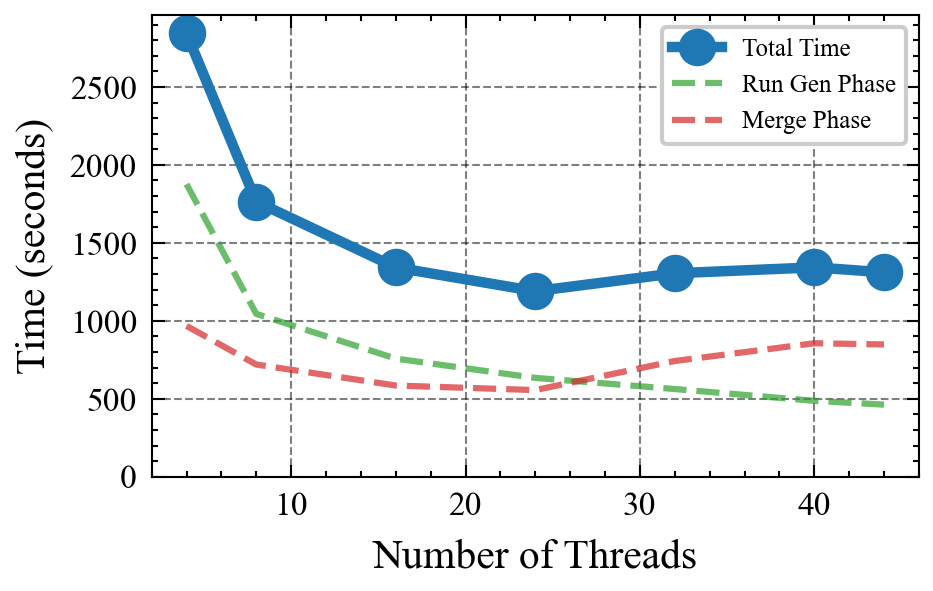


📊 Exp1 Insight: Optimal at 24 threads. Beyond that, run explosion causes 139.0% degradation.


In [91]:
fig, ax1 = plt.subplots()

# Plot 1a: Total time breakdown
df_exp1_sorted = df_exp1.sort_values('threads')
ax1.plot(df_exp1_sorted['threads'], df_exp1_sorted['total_time'], 
         'o-', lw=2.5, markersize=8, color=colors['total'], label='Total Time')
ax1.plot(df_exp1_sorted['threads'], df_exp1_sorted['rungen_time'], 
         '--', lw=1.5, alpha=0.7, color=colors['rungen'], label='Run Gen Phase')
ax1.plot(df_exp1_sorted['threads'], df_exp1_sorted['merge_time'], 
         '--', lw=1.5, alpha=0.7, color=colors['merge'], label='Merge Phase')

# Annotate optimal point
opt_idx = df_exp1_sorted['total_time'].idxmin()
opt_threads = df_exp1_sorted.loc[opt_idx, 'threads']
opt_time = df_exp1_sorted.loc[opt_idx, 'total_time']
# ax1.annotate(f'Optimal\n{int(opt_threads)} threads\n{opt_time:.0f}s',
#              xy=(opt_threads, opt_time), 
#              xytext=(opt_threads, opt_time - 200),
#              arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#              ha='center', fontweight='bold', fontsize=10,
#              bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

ax1.set_xlabel('Number of Threads')
ax1.set_ylabel('Time (seconds)')
# ax1.set_title('Exp1: Scalability Trap (Fixed 2GB RAM)', fontweight='bold')
ax1.legend(loc='best')
ax1.set_ylim(bottom=0)
ax1.grid(True)

# # Plot 1b: Number of runs generated
# ax2.plot(df_exp1_sorted['threads'], df_exp1_sorted['num_runs'], 
#          's-', lw=2, markersize=8, color='#e377c2', label='Runs Generated')
# ax2.set_xlabel('Number of Threads', fontweight='bold')
# ax2.set_ylabel('Number of Runs', fontweight='bold')
# # ax2.set_title('Run Explosion Effect', fontweight='bold')
# ax2.grid()
# ax2.legend()

# plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_scalability_trap.png'), dpi=300)
plt.show()

print(f"\n📊 Exp1 Insight: Optimal at {int(opt_threads)} threads. Beyond that, run explosion causes {(df_exp1_sorted['total_time'].max()/opt_time - 1)*100:.1f}% degradation.")

### Exp1 Speedup Analysis


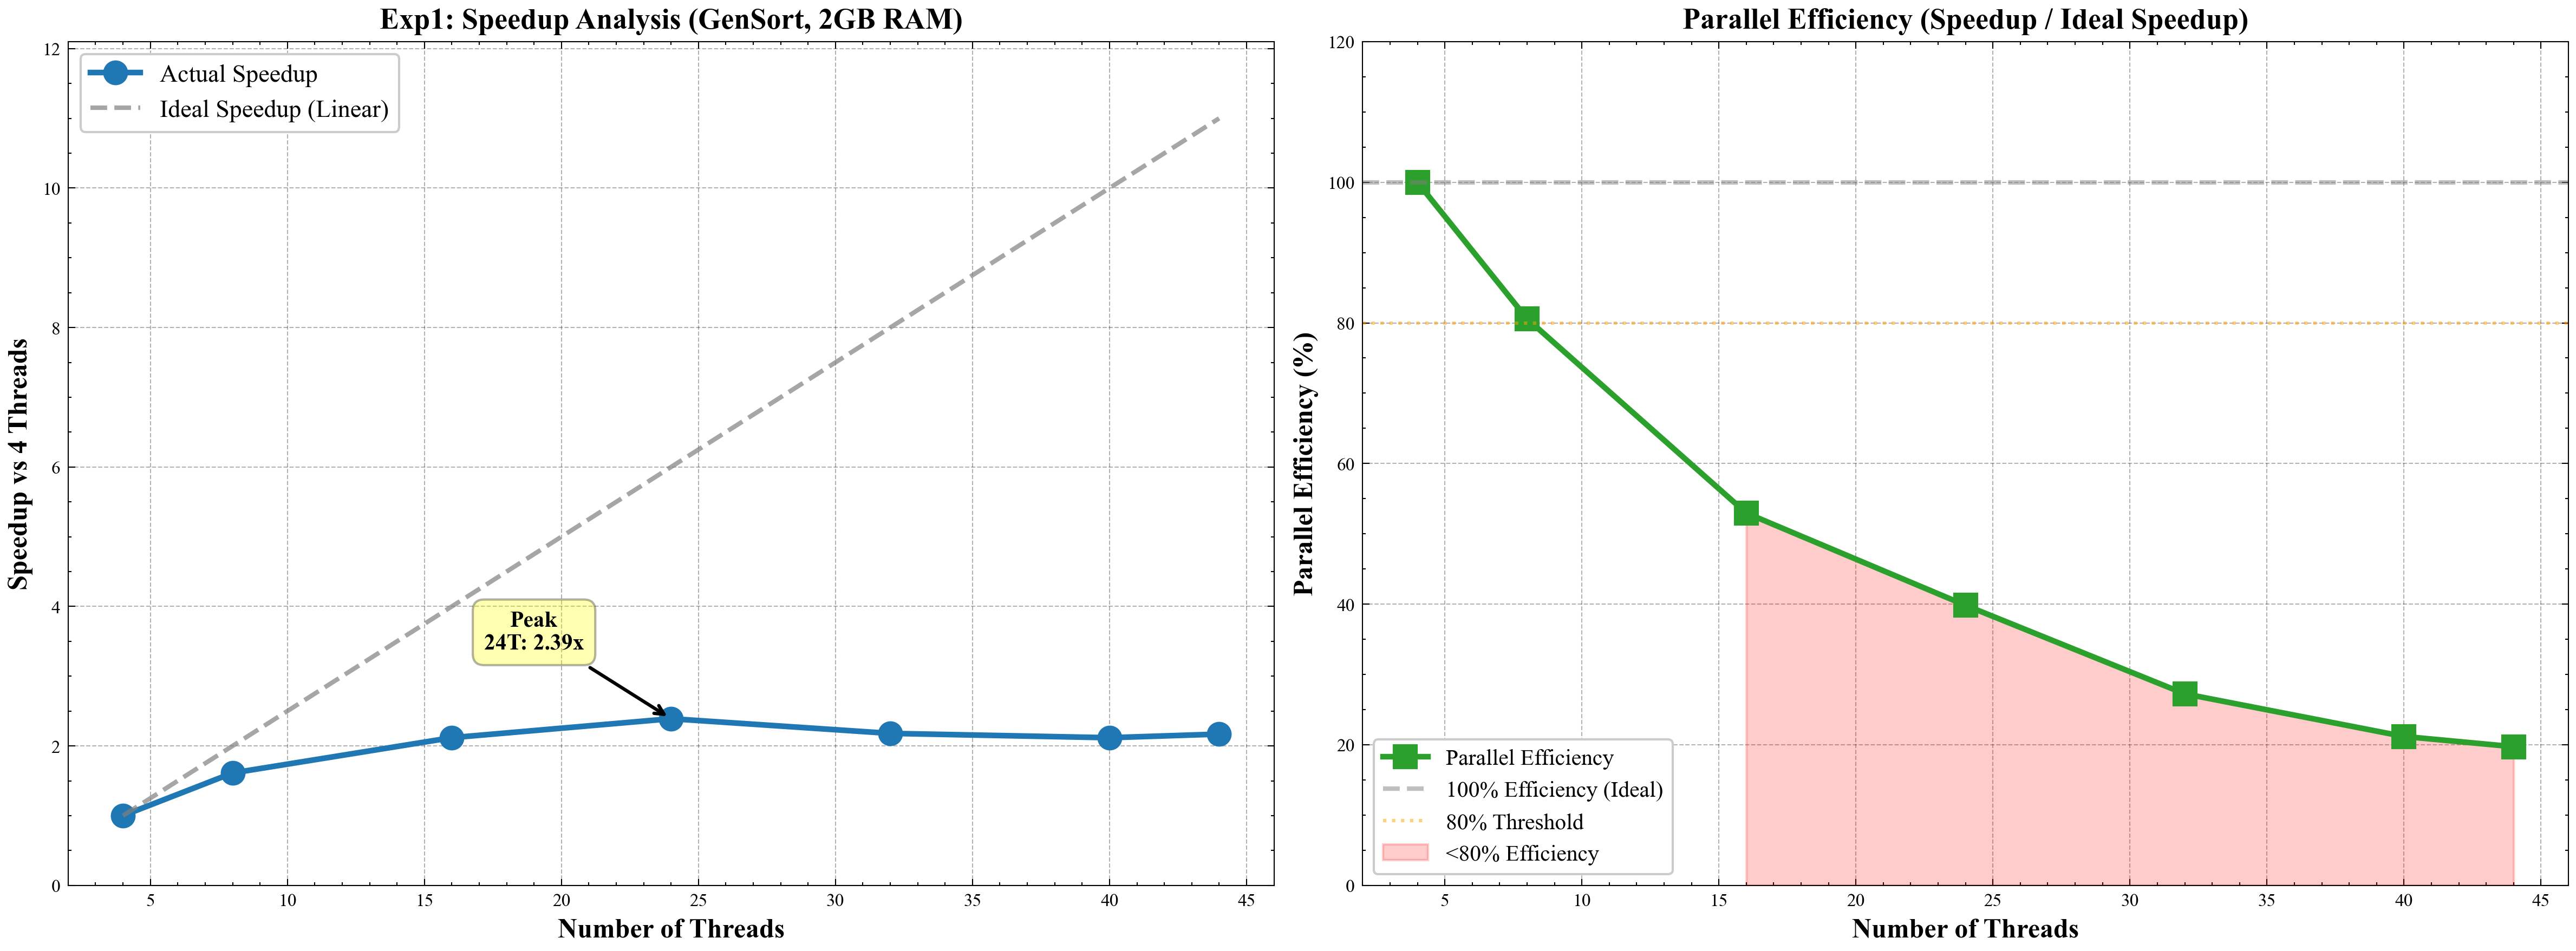


📊 Speedup Analysis Insight:
  - Baseline: 4 threads @ 2843.9s
  - Peak speedup: 2.39x at 24 threads
  - Best efficiency: 100.0% at 4 threads
  - Efficiency drops below 80% at 16 threads

Speedup Table:
 threads  total_time  speedup  ideal_speedup  efficiency_pct
       4     2843.91 1.000000            1.0      100.000000
       8     1764.47 1.611764            2.0       80.588222
      16     1342.61 2.118195            4.0       52.954879
      24     1190.00 2.389840            6.0       39.830672
      32     1304.87 2.179458            8.0       27.243231
      40     1343.01 2.117564           10.0       21.175643
      44     1311.05 2.169185           11.0       19.719864


In [92]:
# Exp1 Speedup Analysis
df_exp1_sorted = df_exp1.sort_values('threads')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Use 4 threads as baseline
baseline_threads = 4
baseline_time = df_exp1_sorted[df_exp1_sorted['threads'] == baseline_threads]['total_time'].values[0]

threads = df_exp1_sorted['threads'].values
times = df_exp1_sorted['total_time'].values

# Calculate speedup
speedup = baseline_time / times

# Calculate ideal speedup (linear scaling)
ideal_speedup = threads / baseline_threads

# Calculate efficiency
efficiency = (speedup / ideal_speedup) * 100

# Plot 1: Speedup
ax1.plot(threads, speedup, 'o-', lw=2.5, markersize=10, color='#1f77b4', label='Actual Speedup')
ax1.plot(threads, ideal_speedup, '--', lw=2, color='gray', alpha=0.7, label='Ideal Speedup (Linear)')

# Annotate optimal point
opt_idx = speedup.argmax()
opt_threads_speedup = threads[opt_idx]
opt_speedup = speedup[opt_idx]
ax1.annotate(f'Peak\n{opt_threads_speedup:.0f}T: {opt_speedup:.2f}x',
             xy=(opt_threads_speedup, opt_speedup), 
             xytext=(opt_threads_speedup - 5, opt_speedup + 1),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             ha='center', fontweight='bold', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

ax1.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
ax1.set_ylabel('Speedup vs 4 Threads', fontweight='bold', fontsize=12)
ax1.set_title('Exp1: Speedup Analysis (GenSort, 2GB RAM)', fontweight='bold', fontsize=13)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_xlim(threads.min() - 2, threads.max() + 2)
ax1.set_ylim(0, max(ideal_speedup.max(), speedup.max()) * 1.1)

# Plot 2: Parallel Efficiency
ax2.plot(threads, efficiency, 's-', lw=2.5, markersize=10, color='#2ca02c', label='Parallel Efficiency')
ax2.axhline(y=100, color='gray', linestyle='--', lw=2, alpha=0.5, label='100% Efficiency (Ideal)')
ax2.axhline(y=80, color='orange', linestyle=':', lw=1.5, alpha=0.5, label='80% Threshold')

# Fill area where efficiency drops below 80%
below_80 = efficiency < 80
if below_80.any():
    ax2.fill_between(threads, 0, efficiency, where=below_80, alpha=0.2, color='red', label='<80% Efficiency')

ax2.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
ax2.set_ylabel('Parallel Efficiency (%)', fontweight='bold', fontsize=12)
ax2.set_title('Parallel Efficiency (Speedup / Ideal Speedup)', fontweight='bold', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_xlim(threads.min() - 2, threads.max() + 2)
ax2.set_ylim(0, 120)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_speedup_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Speedup Analysis Insight:")
print(f"  - Baseline: {baseline_threads} threads @ {baseline_time:.1f}s")
print(f"  - Peak speedup: {opt_speedup:.2f}x at {opt_threads_speedup:.0f} threads")
print(f"  - Best efficiency: {efficiency.max():.1f}% at {threads[efficiency.argmax()]:.0f} threads")
print(f"  - Efficiency drops below 80% at {threads[efficiency < 80][0]:.0f} threads" if (efficiency < 80).any() else "  - Efficiency stays above 80% for all configurations")
print("\nSpeedup Table:")
print(df_exp1_sorted[['threads', 'total_time']].assign(
    speedup=speedup,
    ideal_speedup=ideal_speedup,
    efficiency_pct=efficiency
).to_string(index=False))


### Exp1 Marginal Gain and Cost of Speed Analysis

This analysis shows diminishing returns more intuitively through two complementary visualizations:

**Plot 1: Marginal Gain Bar Chart**
- Shows "what I get for the x-th resource compared to the previous one"
- X-Axis: Thread transitions (e.g., "4→8", "8→12", "12→16")
- Y-Axis: Added throughput per extra thread (entries/s per thread)
- Color gradient: Green (high gains) → Yellow → Red (low/negative gains)
- Reveals: How much benefit each additional thread provides

**Plot 2: Cost of Speed Chart**
- Shows the "hockey stick" - resource cost increases exponentially for higher speeds
- X-Axis: Total throughput (entries/s)
- Y-Axis: Resource cost (thread-seconds = threads × time)
- Highlights: Optimal efficiency point and the exponential cost zone
- Reveals: Where we pay exponentially more for marginal speed increases

**Key Metrics**:
- **Marginal Gain**: Change in throughput per added thread between consecutive configurations
- **Resource Cost**: Total thread-seconds (threads × runtime)
- **Cost Multiplier**: How much more we pay relative to the optimal configuration


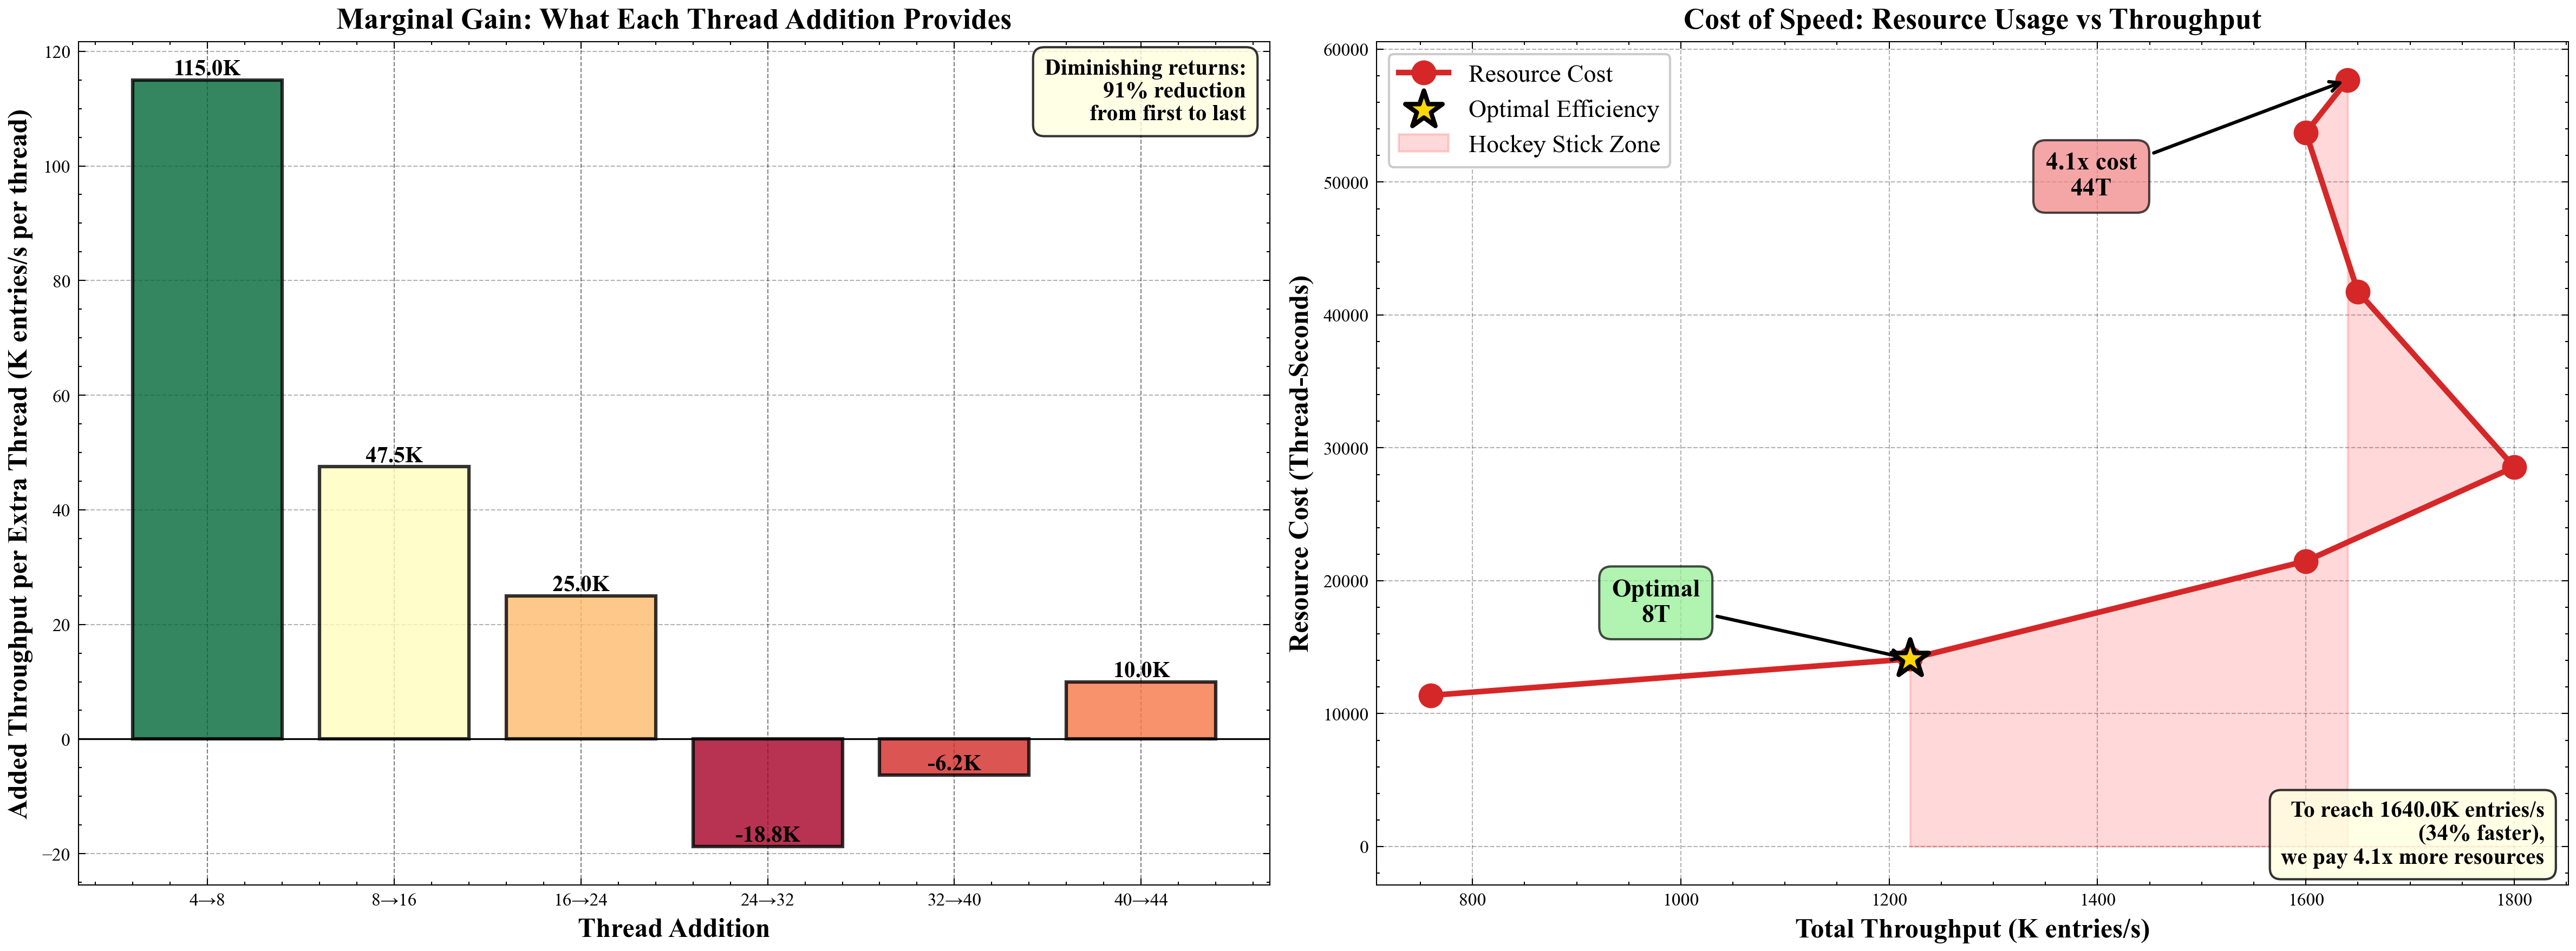


📊 Marginal Gain and Cost Analysis:

Threads Throughput (K) Marginal Gain (K) Resource Cost Cost Multiplier
      4          760.0                 -         11376           0.81x
      8         1220.0             115.0         14116           1.00x
     16         1600.0              47.5         21482           1.52x
     24         1800.0              25.0         28560           2.02x
     32         1650.0             -18.8         41756           2.96x
     40         1600.0              -6.2         53720           3.81x
     44         1640.0              10.0         57686           4.09x

📈 Key Insights:
  - Optimal efficiency: 8 threads (1.00x cost)
  - Maximum throughput: 44 threads (1640.0K entries/s)
  - Cost multiplier at max: 4.1x (paying 4.1x for 34% more speed)
  - First marginal gain: 115.0K entries/s per thread
  - Last marginal gain: 10.0K entries/s per thread
  - Diminishing returns: 91% reduction in marginal gains


In [93]:
# Exp1 Marginal Gain and Cost of Speed Analysis
df_exp1_sorted = df_exp1.sort_values('threads')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

threads = df_exp1_sorted['threads'].values
throughput = df_exp1_sorted['throughput'].values
times = df_exp1_sorted['total_time'].values

# Convert throughput to thousands
throughput_k = throughput * 1000  # Convert millions to thousands

# ========== Plot 1: Marginal Gain Bar Chart ==========
# Calculate marginal gains between consecutive thread counts
marginal_throughput = []
marginal_labels = []
for i in range(1, len(threads)):
    delta_throughput = throughput_k[i] - throughput_k[i-1]
    delta_threads = threads[i] - threads[i-1]
    marginal_gain = delta_throughput / delta_threads  # Added throughput per added thread
    marginal_throughput.append(marginal_gain)
    marginal_labels.append(f"{threads[i-1]:.0f}→{threads[i]:.0f}")

# Color scheme: gradient from green (high gains) to red (low/negative gains)
marginal_array = np.array(marginal_throughput)
max_gain = marginal_array.max()
min_gain = marginal_array.min()

# Normalize to [0, 1] for colormap
if max_gain > min_gain:
    normalized_gains = (marginal_array - min_gain) / (max_gain - min_gain)
else:
    normalized_gains = np.ones_like(marginal_array)

# Use RdYlGn colormap (Red-Yellow-Green)
import matplotlib.cm as cm
bar_colors = [cm.RdYlGn(ng) for ng in normalized_gains]

# Create bar chart
bars = ax1.bar(range(len(marginal_labels)), marginal_throughput, color=bar_colors,
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value annotations on top of bars
for i, (bar, val) in enumerate(zip(bars, marginal_throughput)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}K',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_xlabel('Thread Addition', fontweight='bold', fontsize=12)
ax1.set_ylabel('Added Throughput per Extra Thread (K entries/s per thread)',
               fontweight='bold', fontsize=12)
ax1.set_title('Marginal Gain: What Each Thread Addition Provides',
              fontweight='bold', fontsize=13)
ax1.set_xticks(range(len(marginal_labels)))
ax1.set_xticklabels(marginal_labels, rotation=0, ha='center')
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Calculate diminishing returns
if len(marginal_throughput) > 1:
    first_gain = marginal_throughput[0]
    last_gain = marginal_throughput[-1]
    reduction_pct = ((first_gain - last_gain) / first_gain * 100) if first_gain > 0 else 0
else:
    reduction_pct = 0

# Add annotation for diminishing returns
if len(marginal_throughput) > 1:
    ax1.text(0.98, 0.98, f'Diminishing returns:\n{reduction_pct:.0f}% reduction\nfrom first to last',
             transform=ax1.transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8),
             fontsize=10, fontweight='bold')

# ========== Plot 2: Cost of Speed Chart ==========
# Calculate cost: threads × time (total thread-seconds)
cost_metric = threads * times  # Total thread-seconds

# Find optimal efficiency point (lowest cost per throughput)
cost_per_throughput = cost_metric / throughput
optimal_idx = cost_per_throughput.argmin()
optimal_threads = threads[optimal_idx]
optimal_throughput_k = throughput_k[optimal_idx]
optimal_cost = cost_metric[optimal_idx]

# Calculate cost multiplier relative to optimal
cost_multiplier = cost_metric / cost_metric[optimal_idx]

# Plot line with markers
line = ax2.plot(throughput_k, cost_metric, 'o-', lw=2.5, markersize=10, color='#d62728',
                label='Resource Cost')

# Mark optimal point
ax2.scatter([optimal_throughput_k], [optimal_cost], s=300, marker='*',
            color='gold', edgecolor='black', linewidth=2, zorder=5,
            label='Optimal Efficiency')

# Annotate optimal point
ax2.annotate(f'Optimal\n{optimal_threads:.0f}T',
             xy=(optimal_throughput_k, optimal_cost),
             xytext=(optimal_throughput_k * 0.8, optimal_cost * 1.2),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             ha='center', fontweight='bold', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

# Annotate highest cost point
max_cost_idx = len(cost_metric) - 1
max_threads = threads[max_cost_idx]
max_throughput_k = throughput_k[max_cost_idx]
max_cost = cost_metric[max_cost_idx]
max_multiplier = cost_multiplier[max_cost_idx]

ax2.annotate(f'{max_multiplier:.1f}x cost\n{max_threads:.0f}T',
             xy=(max_throughput_k, max_cost),
             xytext=(max_throughput_k * 0.85, max_cost * 0.85),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             ha='center', fontweight='bold', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7))

# Shade the "hockey stick" region (after optimal point)
if optimal_idx < len(throughput_k) - 1:
    hockey_throughput = throughput_k[optimal_idx:]
    hockey_cost = cost_metric[optimal_idx:]
    ax2.fill_between(hockey_throughput, 0, hockey_cost, alpha=0.15, color='red',
                      label='Hockey Stick Zone')

ax2.set_xlabel('Total Throughput (K entries/s)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Resource Cost (Thread-Seconds)', fontweight='bold', fontsize=12)
ax2.set_title('Cost of Speed: Resource Usage vs Throughput', fontweight='bold', fontsize=13)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)

# Add text annotation about cost increase
throughput_increase = (max_throughput_k / optimal_throughput_k - 1) * 100
ax2.text(0.98, 0.02,
         f'To reach {max_throughput_k:.1f}K entries/s\n({throughput_increase:.0f}% faster),\nwe pay {max_multiplier:.1f}x more resources',
         transform=ax2.transAxes, ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8),
         fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_marginal_gain_analysis_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

# ========== Updated Table Output ==========
print(f"\n📊 Marginal Gain and Cost Analysis:\n")

# Create comprehensive table
table_data = []
for i, t in enumerate(threads):
    row = {
        'Threads': f'{t:.0f}',
        'Throughput (K)': f'{throughput_k[i]:.1f}',
        'Marginal Gain (K)': '-' if i == 0 else f'{marginal_throughput[i-1]:.1f}',
        'Resource Cost': f'{cost_metric[i]:.0f}',
        'Cost Multiplier': f'{cost_multiplier[i]:.2f}x'
    }
    table_data.append(row)

import pandas as pd
table_df = pd.DataFrame(table_data)
print(table_df.to_string(index=False))

print(f"\n📈 Key Insights:")
print(f"  - Optimal efficiency: {optimal_threads:.0f} threads ({cost_multiplier[optimal_idx]:.2f}x cost)")
print(f"  - Maximum throughput: {max_threads:.0f} threads ({max_throughput_k:.1f}K entries/s)")
print(f"  - Cost multiplier at max: {max_multiplier:.1f}x (paying {max_multiplier:.1f}x for {throughput_increase:.0f}% more speed)")
print(f"  - First marginal gain: {marginal_throughput[0]:.1f}K entries/s per thread")
print(f"  - Last marginal gain: {marginal_throughput[-1]:.1f}K entries/s per thread")
print(f"  - Diminishing returns: {reduction_pct:.0f}% reduction in marginal gains")

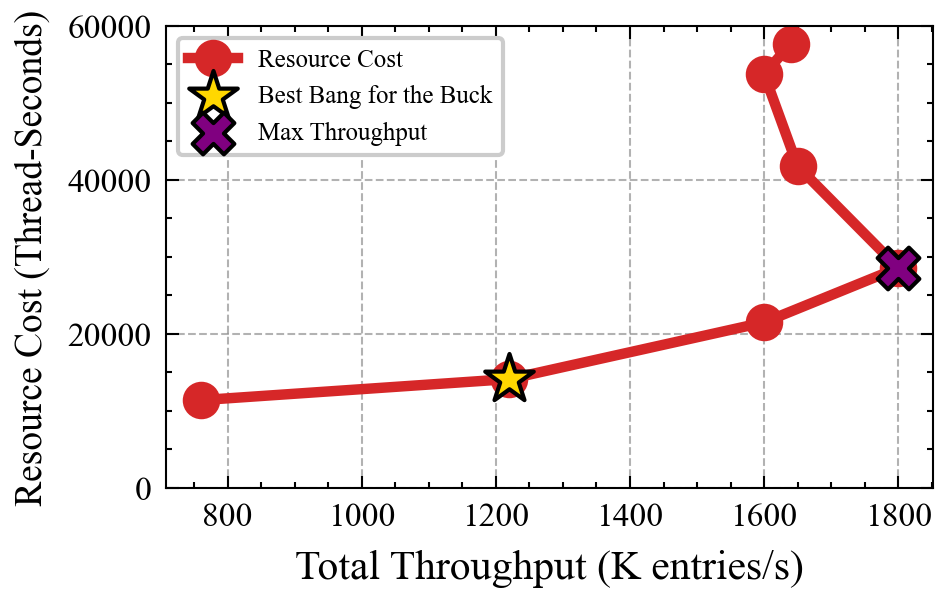


📊 Marginal Gain and Cost Analysis:

Threads Throughput (K) Marginal Gain (K) Resource Cost Cost Multiplier
      4          760.0                 -         11376           0.81x
      8         1220.0             115.0         14116           1.00x
     16         1600.0              47.5         21482           1.52x
     24         1800.0              25.0         28560           2.02x
     32         1650.0             -18.8         41756           2.96x
     40         1600.0              -6.2         53720           3.81x
     44         1640.0              10.0         57686           4.09x

📈 Key Insights:
  - Optimal efficiency: 8 threads (1.00x cost)
  - Maximum throughput: 44 threads (1640.0K entries/s)
  - Cost multiplier at max: 4.1x (paying 4.1x for 34% more speed)
  - First marginal gain: 115.0K entries/s per thread
  - Last marginal gain: 10.0K entries/s per thread
  - Diminishing returns: 91% reduction in marginal gains

📊 Cost / Throughput Table:
 Threads  throughput 

In [94]:
# Exp1 Marginal Gain and Cost of Speed Analysis
df_exp1_sorted = df_exp1.sort_values('threads')

fig, ax2 = plt.subplots()

threads = df_exp1_sorted['threads'].values
throughput = df_exp1_sorted['throughput'].values
times = df_exp1_sorted['total_time'].values

# Convert throughput to thousands
throughput_k = throughput * 1000  # Convert millions to thousands

# ========== Plot 2: Cost of Speed Chart ==========
# Calculate cost: threads × time (total thread-seconds)
cost_metric = threads * times  # Total thread-seconds

# Find optimal efficiency point (lowest cost per throughput)
cost_per_throughput = cost_metric / throughput
optimal_idx = cost_per_throughput.argmin()
optimal_threads = threads[optimal_idx]
optimal_throughput_k = throughput_k[optimal_idx]
optimal_cost = cost_metric[optimal_idx]

# Calculate cost multiplier relative to optimal
cost_multiplier = cost_metric / cost_metric[optimal_idx]

# Plot line with markers
line = ax2.plot(throughput_k, cost_metric, 'o-', lw=2.5, markersize=8, color='#d62728',
                label='Resource Cost')

# Mark optimal point
ax2.scatter([optimal_throughput_k], [optimal_cost], s=150, marker='*',
            color='gold', edgecolor='black', linewidth=1, zorder=5,
            label='Best Bang for the Buck')

# Mark best throughput point
best_throughput_idx = throughput_k.argmax()
ax2.scatter([throughput_k[best_throughput_idx]], [cost_metric[best_throughput_idx]], s=100, marker='X',
            color='purple', edgecolor='black', linewidth=1, zorder=5,
            label='Max Throughput')

# Annotate optimal point
# ax2.annotate(f'Optimal\n{optimal_threads:.0f}T',
#              xy=(optimal_throughput_k, optimal_cost),
#              xytext=(optimal_throughput_k * 0.8, optimal_cost * 1.2),
#              arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#              ha='center', fontweight='bold', fontsize=11,
#              bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

# Annotate highest cost point
max_cost_idx = len(cost_metric) - 1
max_threads = threads[max_cost_idx]
max_throughput_k = throughput_k[max_cost_idx]
max_cost = cost_metric[max_cost_idx]
max_multiplier = cost_multiplier[max_cost_idx]

# ax2.annotate(f'{max_multiplier:.1f}x cost\n{max_threads:.0f}T',
#              xy=(max_throughput_k, max_cost),
#              xytext=(max_throughput_k * 0.85, max_cost * 0.85),
#              arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#              ha='center', fontweight='bold', fontsize=11,
#              bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7))

# Shade the "hockey stick" region (after optimal point)
# if optimal_idx < len(throughput_k) - 1:
#     hockey_throughput = throughput_k[optimal_idx:]
#     hockey_cost = cost_metric[optimal_idx:]
#     ax2.fill_between(hockey_throughput, 0, hockey_cost, alpha=0.15, color='red',
#                       label='Hockey Stick Zone')

ax2.set_xlabel('Total Throughput (K entries/s)')
ax2.set_ylabel('Resource Cost (Thread-Seconds)', fontsize=9)
ax2.set_ylim(bottom=0)
# ax2.set_title('Cost of Speed: Resource Usage vs Throughput', fontweight='bold', fontsize=13)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)

# Add text annotation about cost increase
throughput_increase = (max_throughput_k / optimal_throughput_k - 1) * 100
# ax2.text(0.98, 0.02,
#          f'To reach {max_throughput_k:.1f}K entries/s\n({throughput_increase:.0f}% faster),\nwe pay {max_multiplier:.1f}x more resources',
#          transform=ax2.transAxes, ha='right', va='bottom',
#          bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8),
#          fontsize=10, fontweight='bold')

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_marginal_gain_analysis.png'), dpi=300)
plt.show()

# ========== Updated Table Output ==========
print(f"\n📊 Marginal Gain and Cost Analysis:\n")

# Create comprehensive table
table_data = []
for i, t in enumerate(threads):
    row = {
        'Threads': f'{t:.0f}',
        'Throughput (K)': f'{throughput_k[i]:.1f}',
        'Marginal Gain (K)': '-' if i == 0 else f'{marginal_throughput[i-1]:.1f}',
        'Resource Cost': f'{cost_metric[i]:.0f}',
        'Cost Multiplier': f'{cost_multiplier[i]:.2f}x'
    }
    table_data.append(row)

import pandas as pd
table_df = pd.DataFrame(table_data)
print(table_df.to_string(index=False))

print(f"\n📈 Key Insights:")
print(f"  - Optimal efficiency: {optimal_threads:.0f} threads ({cost_multiplier[optimal_idx]:.2f}x cost)")
print(f"  - Maximum throughput: {max_threads:.0f} threads ({max_throughput_k:.1f}K entries/s)")
print(f"  - Cost multiplier at max: {max_multiplier:.1f}x (paying {max_multiplier:.1f}x for {throughput_increase:.0f}% more speed)")
print(f"  - First marginal gain: {marginal_throughput[0]:.1f}K entries/s per thread")
print(f"  - Last marginal gain: {marginal_throughput[-1]:.1f}K entries/s per thread")
print(f"  - Diminishing returns: {reduction_pct:.0f}% reduction in marginal gains")

# Print cost / throughput table
print(f"\n📊 Cost / Throughput Table:")
print(df_exp1_sorted[['threads', 'throughput']].assign(
    throughput_k=lambda x: x['throughput'] * 1000,
    resource_cost=lambda x: x['threads'] * df_exp1_sorted['total_time'],
    cost_per_throughput=lambda x: (x['threads'] * df_exp1_sorted['total_time']) / x['throughput'],
).rename(columns={
    'threads': 'Threads',
    'throughput_k': 'Throughput (K entries/s)',
    'resource_cost': 'Resource Cost (Thread-Seconds)',
    'cost_per_throughput': 'Cost per Throughput (Thread-Seconds per Million entries/s)'
}).to_string(index=False))

### Efficiency Diagnosis: Root Cause Analysis


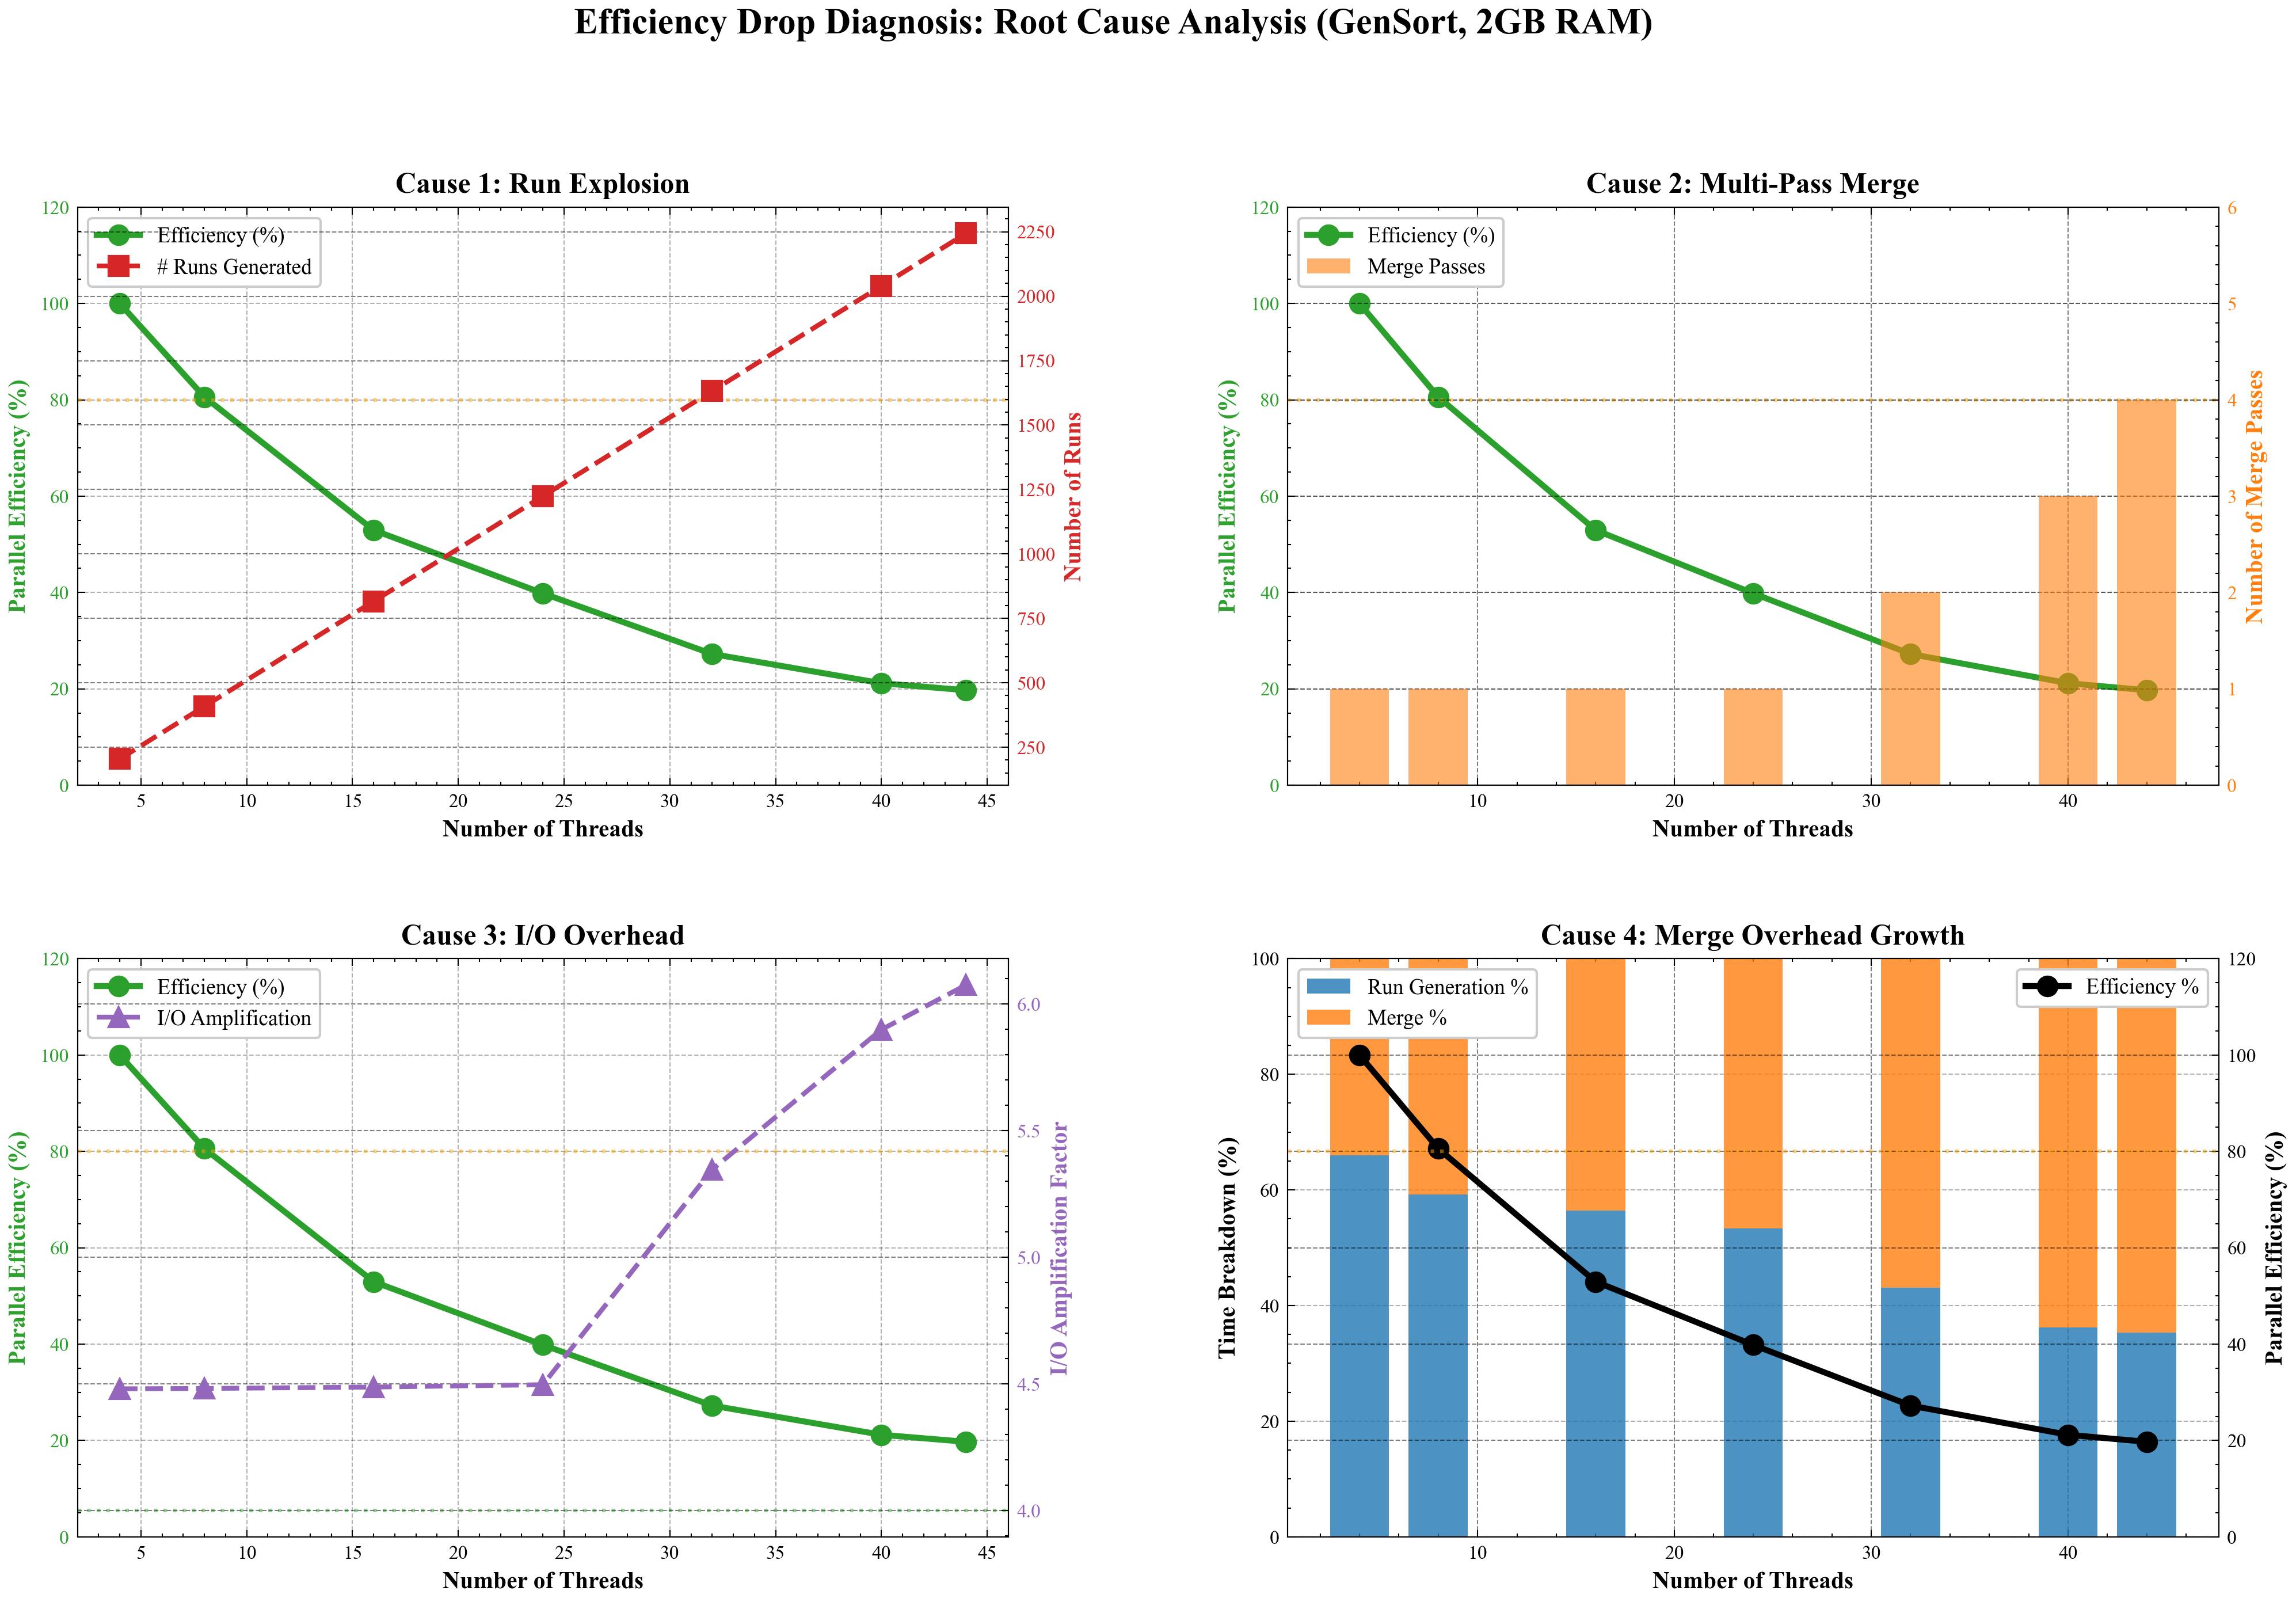


🔍 Efficiency Diagnosis:

1. Run Explosion:
   - At 4 threads: 204 runs, 100.0% efficient
   - At 44 threads: 2244 runs, 19.7% efficient
   - Run count increased by 1000.0%

2. Multi-Pass Merge Transition:
   - Single-pass: 4-24 threads
   - Multi-pass starts at: 32 threads (2 passes)
   - Efficiency at transition: 27.2%

3. I/O Amplification:
   - At 4 threads: 4.48x I/O amplification
   - At 44 threads: 6.07x I/O amplification
   - I/O overhead increased by 35.6%

4. Merge Time Growth:
   - At 4 threads: Merge = 34.0% of total time
   - At 44 threads: Merge = 64.7% of total time
   - Merge overhead grew from 34.0% to 64.7%


In [95]:
# Efficiency Diagnosis: Multi-metric correlation analysis
df_exp1_sorted = df_exp1.sort_values('threads')

# Calculate baseline metrics
baseline_threads = 4
baseline_time = df_exp1_sorted[df_exp1_sorted['threads'] == baseline_threads]['total_time'].values[0]
threads = df_exp1_sorted['threads'].values
speedup = baseline_time / df_exp1_sorted['total_time'].values
ideal_speedup = threads / baseline_threads
efficiency = (speedup / ideal_speedup) * 100

# Create figure with 4 subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ------------------------------
# Plot 1: Efficiency vs Run Count
# ------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1_twin = ax1.twinx()

# Efficiency (left y-axis)
line1 = ax1.plot(threads, efficiency, 'o-', lw=2.5, markersize=8, color='#2ca02c', label='Efficiency (%)')
ax1.axhline(y=80, color='orange', linestyle=':', lw=1.5, alpha=0.5)
ax1.set_xlabel('Number of Threads', fontweight='bold')
ax1.set_ylabel('Parallel Efficiency (%)', fontweight='bold', color='#2ca02c')
ax1.tick_params(axis='y', labelcolor='#2ca02c')
ax1.set_ylim(0, 120)

# Run count (right y-axis)
num_runs = df_exp1_sorted['num_runs'].values
line2 = ax1_twin.plot(threads, num_runs, 's--', lw=2, markersize=8, color='#d62728', label='# Runs Generated')
ax1_twin.set_ylabel('Number of Runs', fontweight='bold', color='#d62728')
ax1_twin.tick_params(axis='y', labelcolor='#d62728')

ax1.set_title('Cause 1: Run Explosion', fontweight='bold', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=9)

# ------------------------------
# Plot 2: Efficiency vs Merge Passes
# ------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2_twin = ax2.twinx()

# Efficiency (left y-axis)
line1 = ax2.plot(threads, efficiency, 'o-', lw=2.5, markersize=8, color='#2ca02c', label='Efficiency (%)')
ax2.axhline(y=80, color='orange', linestyle=':', lw=1.5, alpha=0.5)
ax2.set_xlabel('Number of Threads', fontweight='bold')
ax2.set_ylabel('Parallel Efficiency (%)', fontweight='bold', color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.set_ylim(0, 120)

# Merge passes (right y-axis)
merge_passes = df_exp1_sorted['merge_passes'].values
line2 = ax2_twin.bar(threads, merge_passes, width=3, alpha=0.6, color='#ff7f0e', label='Merge Passes')
ax2_twin.set_ylabel('Number of Merge Passes', fontweight='bold', color='#ff7f0e')
ax2_twin.tick_params(axis='y', labelcolor='#ff7f0e')
ax2_twin.set_ylim(0, merge_passes.max() * 1.5)

ax2.set_title('Cause 2: Multi-Pass Merge', fontweight='bold', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')
lines = line1 + [line2]
labels = [line1[0].get_label(), 'Merge Passes']
ax2.legend(lines, labels, loc='upper left', fontsize=9)

# ------------------------------
# Plot 3: Efficiency vs I/O Amplification
# ------------------------------
ax3 = fig.add_subplot(gs[1, 0])
ax3_twin = ax3.twinx()

# Efficiency (left y-axis)
line1 = ax3.plot(threads, efficiency, 'o-', lw=2.5, markersize=8, color='#2ca02c', label='Efficiency (%)')
ax3.axhline(y=80, color='orange', linestyle=':', lw=1.5, alpha=0.5)
ax3.set_xlabel('Number of Threads', fontweight='bold')
ax3.set_ylabel('Parallel Efficiency (%)', fontweight='bold', color='#2ca02c')
ax3.tick_params(axis='y', labelcolor='#2ca02c')
ax3.set_ylim(0, 120)

# I/O amplification (right y-axis)
input_size_mb = 204800
total_io = df_exp1_sorted['total_io_mb'].values
io_amp = total_io / input_size_mb
line2 = ax3_twin.plot(threads, io_amp, '^--', lw=2, markersize=8, color='#9467bd', label='I/O Amplification')
ax3_twin.axhline(y=4.0, color='green', linestyle=':', lw=1.5, alpha=0.4)
ax3_twin.set_ylabel('I/O Amplification Factor', fontweight='bold', color='#9467bd')
ax3_twin.tick_params(axis='y', labelcolor='#9467bd')

ax3.set_title('Cause 3: I/O Overhead', fontweight='bold', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='upper left', fontsize=9)

# ------------------------------
# Plot 4: Time Breakdown Analysis
# ------------------------------
ax4 = fig.add_subplot(gs[1, 1])

rungen_time = df_exp1_sorted['rungen_time'].values
merge_time = df_exp1_sorted['merge_time'].values
total_time = df_exp1_sorted['total_time'].values

# Calculate percentages
rungen_pct = (rungen_time / total_time) * 100
merge_pct = (merge_time / total_time) * 100

# Stacked bar chart
width = 3
ax4.bar(threads, rungen_pct, width, label='Run Generation %', color='#1f77b4', alpha=0.8)
ax4.bar(threads, merge_pct, width, bottom=rungen_pct, label='Merge %', color='#ff7f0e', alpha=0.8)

# Add efficiency line
ax4_twin = ax4.twinx()
line = ax4_twin.plot(threads, efficiency, 'ko-', lw=2.5, markersize=8, label='Efficiency %')
ax4_twin.set_ylabel('Parallel Efficiency (%)', fontweight='bold')
ax4_twin.set_ylim(0, 120)
ax4_twin.axhline(y=80, color='orange', linestyle=':', lw=1.5, alpha=0.5)

ax4.set_xlabel('Number of Threads', fontweight='bold')
ax4.set_ylabel('Time Breakdown (%)', fontweight='bold')
ax4.set_title('Cause 4: Merge Overhead Growth', fontweight='bold', fontsize=12)
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)
ax4.grid(True, linestyle='--', alpha=0.3, axis='y')
ax4.set_ylim(0, 100)

fig.suptitle('Efficiency Drop Diagnosis: Root Cause Analysis (GenSort, 2GB RAM)', 
             fontsize=15, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_efficiency_diagnosis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n🔍 Efficiency Diagnosis:")
print("\n1. Run Explosion:")
print(f"   - At {threads[0]:.0f} threads: {num_runs[0]} runs, {efficiency[0]:.1f}% efficient")
print(f"   - At {threads[-1]:.0f} threads: {num_runs[-1]} runs, {efficiency[-1]:.1f}% efficient")
print(f"   - Run count increased by {(num_runs[-1]/num_runs[0] - 1)*100:.1f}%")

print("\n2. Multi-Pass Merge Transition:")
single_pass = threads[merge_passes == 1]
multi_pass = threads[merge_passes > 1]
if len(multi_pass) > 0:
    transition_idx = list(merge_passes).index(merge_passes[merge_passes > 1][0])
    print(f"   - Single-pass: {single_pass.min():.0f}-{single_pass.max():.0f} threads")
    print(f"   - Multi-pass starts at: {multi_pass.min():.0f} threads ({merge_passes[transition_idx]:.0f} passes)")
    print(f"   - Efficiency at transition: {efficiency[transition_idx]:.1f}%")

print("\n3. I/O Amplification:")
print(f"   - At {threads[0]:.0f} threads: {io_amp[0]:.2f}x I/O amplification")
print(f"   - At {threads[-1]:.0f} threads: {io_amp[-1]:.2f}x I/O amplification")
print(f"   - I/O overhead increased by {(io_amp[-1]/io_amp[0] - 1)*100:.1f}%")

print("\n4. Merge Time Growth:")
print(f"   - At {threads[0]:.0f} threads: Merge = {merge_pct[0]:.1f}% of total time")
print(f"   - At {threads[-1]:.0f} threads: Merge = {merge_pct[-1]:.1f}% of total time")
print(f"   - Merge overhead grew from {merge_pct[0]:.1f}% to {merge_pct[-1]:.1f}%")


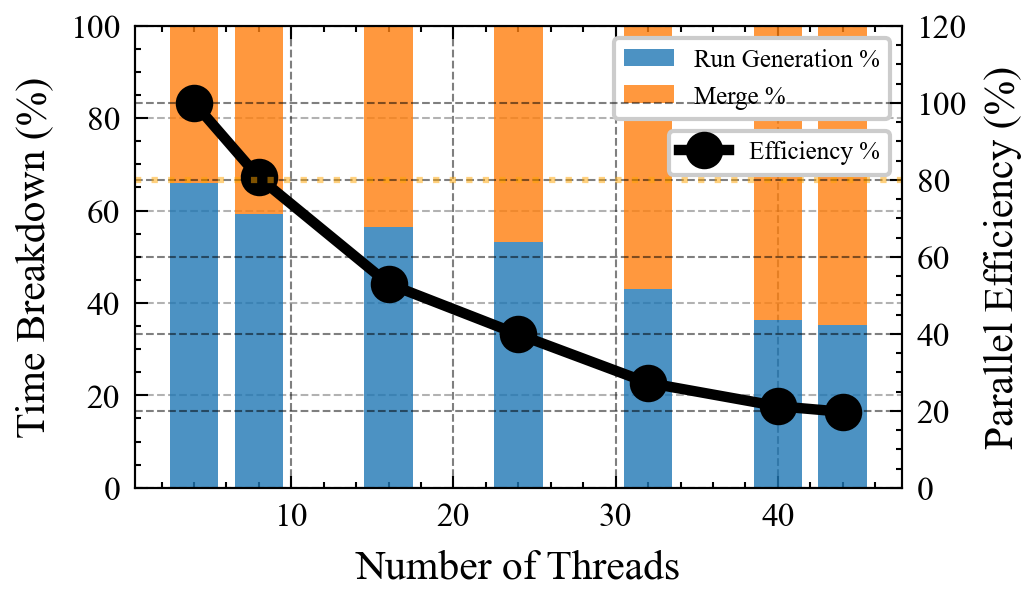

In [96]:
fig, ax4 = plt.subplots()
# ------------------------------
# Plot 4: Time Breakdown Analysis
# ------------------------------

rungen_time = df_exp1_sorted['rungen_time'].values
merge_time = df_exp1_sorted['merge_time'].values
total_time = df_exp1_sorted['total_time'].values

# Calculate percentages
rungen_pct = (rungen_time / total_time) * 100
merge_pct = (merge_time / total_time) * 100

# Stacked bar chart
width = 3
ax4.bar(threads, rungen_pct, width, label='Run Generation %', color='#1f77b4', alpha=0.8)
ax4.bar(threads, merge_pct, width, bottom=rungen_pct, label='Merge %', color='#ff7f0e', alpha=0.8)

# Add efficiency line
ax4_twin = ax4.twinx()
line = ax4_twin.plot(threads, efficiency, 'ko-', lw=2.5, markersize=8, label='Efficiency %')
ax4_twin.set_ylabel('Parallel Efficiency (%)')
ax4_twin.set_ylim(0, 120)
ax4_twin.axhline(y=80, color='orange', linestyle=':', lw=1.5, alpha=0.5)

ax4.set_xlabel('Number of Threads')
ax4.set_ylabel('Time Breakdown (%)')
# ax4.set_title('Cause 4: Merge Overhead Growth', fontweight='bold', fontsize=12)
ax4.grid(True, linestyle='--', alpha=0.3, axis='y')
ax4.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax4_twin.legend(loc='upper right', bbox_to_anchor=(1, 0.8))
ax4.set_ylim(0, 100)

# fig.suptitle('Efficiency Drop Diagnosis: Root Cause Analysis (GenSort, 2GB RAM)', 
#              fontsize=15, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_efficiency_diagnosis.png'), dpi=300)
plt.show()

### Exp1 I/O Analysis: Multi-Pass Merge Overhead

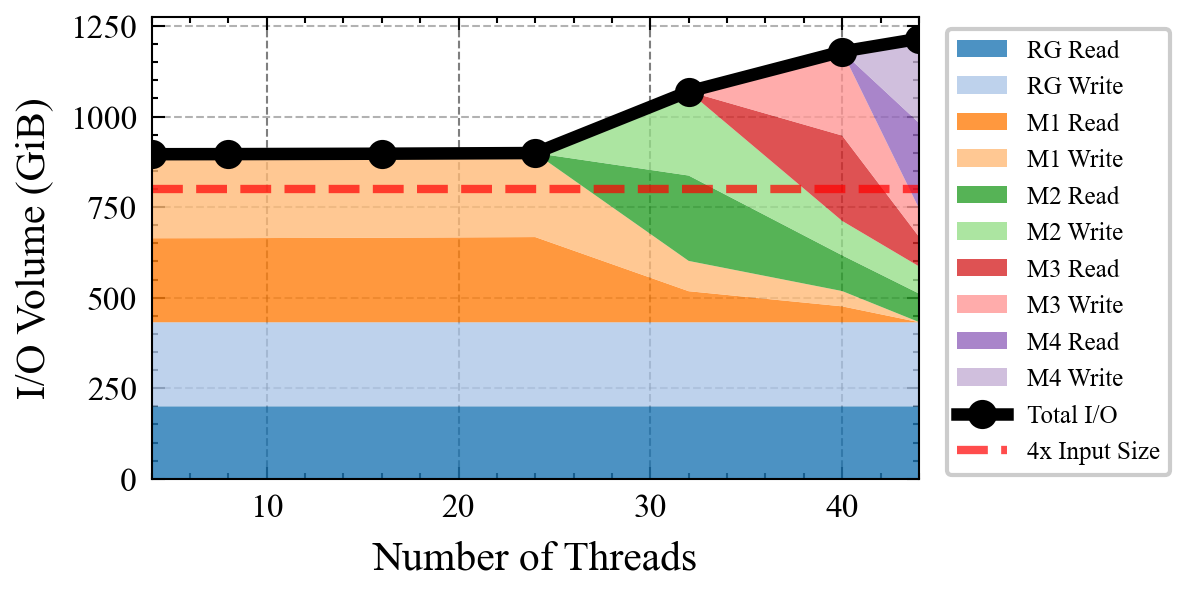


📊 I/O Analysis Insight:
  - Low threads (4-16): Single-pass merge, I/O amp ~4.48x
  - High threads (32-44): Multi-pass merge, I/O amp ~5.77x
  - Overhead increase: 28.8%

I/O Breakdown (GiB):
 threads  merge_passes  rg_read_mb  rg_write_mb  m1_read_mb  m1_write_mb  m2_read_mb  m2_write_mb  m3_read_mb  m3_write_mb  m4_read_mb  m4_write_mb  total_io_mb
       4             1  200.000000        232.0  232.082129   232.000000    0.000000     0.000000    0.000000     0.000000    0.000000          0.0   896.082129
       8             1  200.000000        232.0  232.355664   232.000000    0.000000     0.000000    0.000000     0.000000    0.000000          0.0   896.355664
      16             1  200.000000        232.0  233.454883   232.000000    0.000000     0.000000    0.000000     0.000000    0.000000          0.0   897.454883
      24             1  200.001367        232.0  235.313770   232.000000    0.000000     0.000000    0.000000     0.000000    0.000000          0.0   899.315137
  

In [97]:
# Exp1 I/O Analysis: Visualize multi-pass merge overhead
df_exp1_sorted = df_exp1.sort_values('threads')

fig, ax1 = plt.subplots()

# Plot 1: Stacked area chart of I/O operations (convert MB to GiB)
threads = df_exp1_sorted['threads'].values
rg_read = df_exp1_sorted['rg_read_mb'].values / 1024
rg_write = df_exp1_sorted['rg_write_mb'].values / 1024
m1_read = df_exp1_sorted['m1_read_mb'].values / 1024
m1_write = df_exp1_sorted['m1_write_mb'].values / 1024
m2_read = df_exp1_sorted['m2_read_mb'].values / 1024
m2_write = df_exp1_sorted['m2_write_mb'].values / 1024
m3_read = df_exp1_sorted['m3_read_mb'].values / 1024
m3_write = df_exp1_sorted['m3_write_mb'].values / 1024
m4_read = df_exp1_sorted['m4_read_mb'].values / 1024
m4_write = df_exp1_sorted['m4_write_mb'].values / 1024

# Create stacked data
io_components = [rg_read, rg_write, m1_read, m1_write, m2_read, m2_write, m3_read, m3_write, m4_read, m4_write]
labels = ['RG Read', 'RG Write', 'M1 Read', 'M1 Write', 'M2 Read', 'M2 Write', 'M3 Read', 'M3 Write', 'M4 Read', 'M4 Write']
colors_io = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5']

ax1.stackplot(threads, *io_components, labels=labels, colors=colors_io, alpha=0.8)

# Add total I/O line
total_io = df_exp1_sorted['total_io_mb'].values / 1024
ax1.plot(threads, total_io, 'k-', lw=3, label='Total I/O', marker='o', markersize=6)

# Add horizontal line at 4x input size (200 GiB * 4 = 800 GiB)
ax1.axhline(y=800, color='red', linestyle='--', lw=2, alpha=0.7, label='4x Input Size')

ax1.set_xlabel('Number of Threads')
ax1.set_ylabel('I/O Volume (GiB)')
# ax1.set_title('Exp1: I/O Breakdown by Operation (2GB RAM)', fontweight='bold', fontsize=13)
# set legend on top of plot
ax1.legend(loc='upper left', fontsize=6, bbox_to_anchor=(1.02, 1))
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')
ax1.set_xlim(threads.min(), threads.max())

# plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_io_analysis.png'), dpi=300)
plt.show()

# Calculate I/O amplification for summary
input_size_gib = 200  # 200 GiB input
io_amplification = total_io / input_size_gib

print(f"\n📊 I/O Analysis Insight:")
print(f"  - Low threads (4-16): Single-pass merge, I/O amp ~{io_amplification[threads <= 16].mean():.2f}x")
print(f"  - High threads (32-44): Multi-pass merge, I/O amp ~{io_amplification[threads >= 32].mean():.2f}x")
print(f"  - Overhead increase: {(io_amplification[threads >= 32].mean() / io_amplification[threads <= 16].mean() - 1)*100:.1f}%")
print("\nI/O Breakdown (GiB):")
print(df_exp1_sorted[['threads', 'merge_passes', 'rg_read_mb', 'rg_write_mb', 'm1_read_mb', 'm1_write_mb', 
                      'm2_read_mb', 'm2_write_mb', 'm3_read_mb', 'm3_write_mb', 'm4_read_mb', 'm4_write_mb', 'total_io_mb']].apply(lambda x: x/1024 if x.name != 'threads' and x.name != 'merge_passes' else x).to_string(index=False))


### Exp1 I/O Speed Analysis


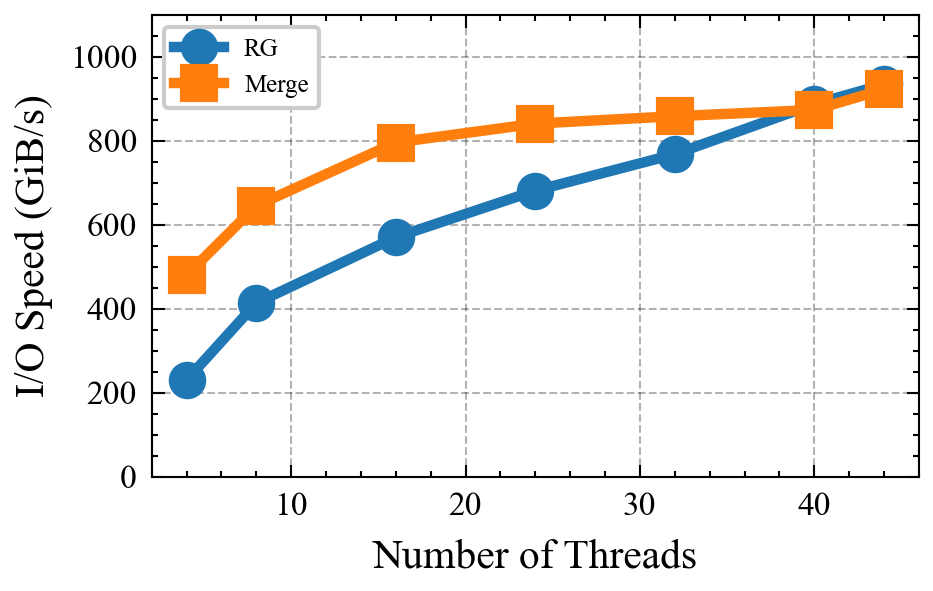


📊 I/O Speed Analysis:

Run Generation:
  - Peak I/O speed: 934.2 GiB/s at 44 threads
  - Lowest I/O speed: 230.2 GiB/s at 4 threads
  - Speed variation: 305.8%

Merge Phase:
  - Peak I/O speed: 922.5 GiB/s at 44 threads
  - Lowest I/O speed: 479.7 GiB/s at 4 threads
  - Speed variation: 92.3%

Comparison:
  - Avg RG speed: 640.6 GiB/s
  - Avg Merge speed: 773.7 GiB/s
  - Merge is 20.8% faster than RG

I/O Speed Table:
 threads  rungen_time  merge_time  rg_io_speed_gibs  merge_io_speed_gibs
       4      1876.57      967.35             230.2                479.7
       8      1044.71      719.76             413.5                645.2
      16       757.63      584.97             570.2                795.7
      24       634.20      555.80             681.2                840.8
      32       562.60      742.27             767.9                858.4
      40       486.97      856.04             887.1                873.4
      44       462.44      848.61             934.2               

In [98]:
# Exp1 I/O Speed Analysis: RG and Merge I/O Throughput
df_exp1_sorted = df_exp1.sort_values('threads')

fig, ax2 = plt.subplots()

threads = df_exp1_sorted['threads'].values

# Calculate I/O speeds (GiB/s)
# RG I/O speed = (RG Read + RG Write) / RG Time
rg_io_speed = ((df_exp1_sorted['rg_read_mb'].values + df_exp1_sorted['rg_write_mb'].values) / 
               (df_exp1_sorted['rungen_time'].values / 1000)) / 1024  # Convert MiB/s to GiB/s

# Merge I/O speed = (Total Merge Read + Total Merge Write) / Merge Time
merge_read = (df_exp1_sorted['m1_read_mb'].values + df_exp1_sorted['m2_read_mb'].values + 
              df_exp1_sorted['m3_read_mb'].values + df_exp1_sorted['m4_read_mb'].values)
merge_write = (df_exp1_sorted['m1_write_mb'].values + df_exp1_sorted['m2_write_mb'].values + 
               df_exp1_sorted['m3_write_mb'].values + df_exp1_sorted['m4_write_mb'].values)
merge_io_speed = (merge_read + merge_write) / (df_exp1_sorted['merge_time'].values / 1000) / 1024  # Convert MiB/s to GiB/s

# ------------------------------
# Plot 1: I/O Speed by Phase
# ------------------------------
# width = 2.5
# x_offset = 1.5
# 
# ax1.bar(threads - x_offset, rg_io_speed, width, label='Run Generation I/O Speed', 
#         color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1)
# ax1.bar(threads + x_offset, merge_io_speed, width, label='Merge I/O Speed', 
#         color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=1)
# 
# ax1.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
# ax1.set_ylabel('I/O Speed (GiB/s)', fontweight='bold', fontsize=12)
# ax1.set_title('I/O Throughput: Run Generation vs Merge', fontweight='bold', fontsize=13)
# ax1.legend(fontsize=11)
# ax1.grid(True, linestyle='--', alpha=0.3, axis='y')
# ax1.set_xticks(threads)

# ------------------------------
# Plot 2: I/O Speed Trends
# ------------------------------
ax2.plot(threads, rg_io_speed, 'o-', lw=2.5, markersize=8, color='#1f77b4', label='RG')
ax2.plot(threads, merge_io_speed, 's-', lw=2.5, markersize=8, color='#ff7f0e', label='Merge')

# Annotate peak speeds
rg_peak_idx = rg_io_speed.argmax()
merge_peak_idx = merge_io_speed.argmax()

# ax2.annotate(f'Peak RG\n{rg_io_speed[rg_peak_idx]:.1f} GiB/s',
#              xy=(threads[rg_peak_idx], rg_io_speed[rg_peak_idx]),
#              xytext=(threads[rg_peak_idx] - 8, rg_io_speed[rg_peak_idx] + 500),
#              arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.5),
#              ha='center', fontweight='bold', fontsize=9,
#              bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#1f77b4', alpha=0.8))
# 
# ax2.annotate(f'Peak Merge\n{merge_io_speed[merge_peak_idx]:.1f} GiB/s',
#              xy=(threads[merge_peak_idx], merge_io_speed[merge_peak_idx]),
#              xytext=(threads[merge_peak_idx] + 8, merge_io_speed[merge_peak_idx] - 500),
#              arrowprops=dict(arrowstyle='->', color='#ff7f0e', lw=1.5),
#              ha='center', fontweight='bold', fontsize=9,
#              bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ff7f0e', alpha=0.8))

ax2.set_xlabel('Number of Threads')
ax2.set_ylabel('I/O Speed (GiB/s)')
# ax2.set_title('I/O Speed Scaling with Thread Count', fontweight='bold', fontsize=13)
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_xlim(threads.min() - 2, threads.max() + 2)
ax2.set_ylim(bottom=0, top=1100)

# plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp1_io_speed.png'), dpi=300)
plt.show()

print(f"\n📊 I/O Speed Analysis:")
print(f"\nRun Generation:")
print(f"  - Peak I/O speed: {rg_io_speed.max():.1f} GiB/s at {threads[rg_peak_idx]:.0f} threads")
print(f"  - Lowest I/O speed: {rg_io_speed.min():.1f} GiB/s at {threads[rg_io_speed.argmin()]:.0f} threads")
print(f"  - Speed variation: {(rg_io_speed.max() / rg_io_speed.min() - 1)*100:.1f}%")

print(f"\nMerge Phase:")
print(f"  - Peak I/O speed: {merge_io_speed.max():.1f} GiB/s at {threads[merge_peak_idx]:.0f} threads")
print(f"  - Lowest I/O speed: {merge_io_speed.min():.1f} GiB/s at {threads[merge_io_speed.argmin()]:.0f} threads")
print(f"  - Speed variation: {(merge_io_speed.max() / merge_io_speed.min() - 1)*100:.1f}%")

print(f"\nComparison:")
print(f"  - Avg RG speed: {rg_io_speed.mean():.1f} GiB/s")
print(f"  - Avg Merge speed: {merge_io_speed.mean():.1f} GiB/s")
print(f"  - Merge is {(merge_io_speed.mean() / rg_io_speed.mean() - 1)*100:.1f}% {'faster' if merge_io_speed.mean() > rg_io_speed.mean() else 'slower'} than RG")

print("\nI/O Speed Table:")
print(df_exp1_sorted[['threads', 'rungen_time', 'merge_time']].assign(
    rg_io_speed_gibs=rg_io_speed.round(1),
    merge_io_speed_gibs=merge_io_speed.round(1)
).to_string(index=False))


In [99]:
# Exp1.1 and Exp1.2: Individual Thread Impact Analysis
print("="*100)
print("EXP1.1: FIXED RUNGEN=40, VARYING MERGE THREADS")
print("="*100)

# Load Exp1.1 data (fixed RunGen=40, varying Merge threads)
exp1_1_files = glob.glob(os.path.join(LOG_DIR, 'Exp1.1_*.log'))
exp1_1_data = []
for filepath in exp1_1_files:
    parsed = parse_exp1_subexp_log(filepath)
    if parsed:
        exp1_1_data.append(parsed)

df_exp1_1 = pd.DataFrame(exp1_1_data).sort_values('merge_threads')
display_cols = ['rungen_threads', 'merge_threads', 'total_time', 'rungen_time', 'merge_time',
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp1_1[display_cols].to_string(index=False))

print("\n" + "="*100)
print("EXP1.2: FIXED MERGE=40, VARYING RUNGEN THREADS")
print("="*100)

# Load Exp1.2 data (varying RunGen threads, fixed Merge=40)
exp1_2_files = glob.glob(os.path.join(LOG_DIR, 'Exp1.2_*.log'))
exp1_2_data = []
for filepath in exp1_2_files:
    parsed = parse_exp1_subexp_log(filepath)
    if parsed:
        exp1_2_data.append(parsed)

df_exp1_2 = pd.DataFrame(exp1_2_data).sort_values('rungen_threads')
print(df_exp1_2[display_cols].to_string(index=False))


EXP1.1: FIXED RUNGEN=40, VARYING MERGE THREADS
 rungen_threads  merge_threads  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
             40              4     1287.68       436.81      850.87        1.67           NaN                1.00
             40              8     1062.53       438.48      624.05        2.02           NaN                1.01
             40             16      940.43       438.59      501.84        2.28           NaN                1.02
             40             24     1056.17       436.88      619.29        2.03           2.0                1.34
             40             32     1199.26       464.86      734.39        1.79           2.0                1.52
             40             40     1176.15       450.31      725.85        1.83           3.0                1.63

EXP1.2: FIXED MERGE=40, VARYING RUNGEN THREADS
 rungen_threads  merge_threads  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplifi

### Exp1.1/1.2: RunGen vs Merge Thread Impact Analysis


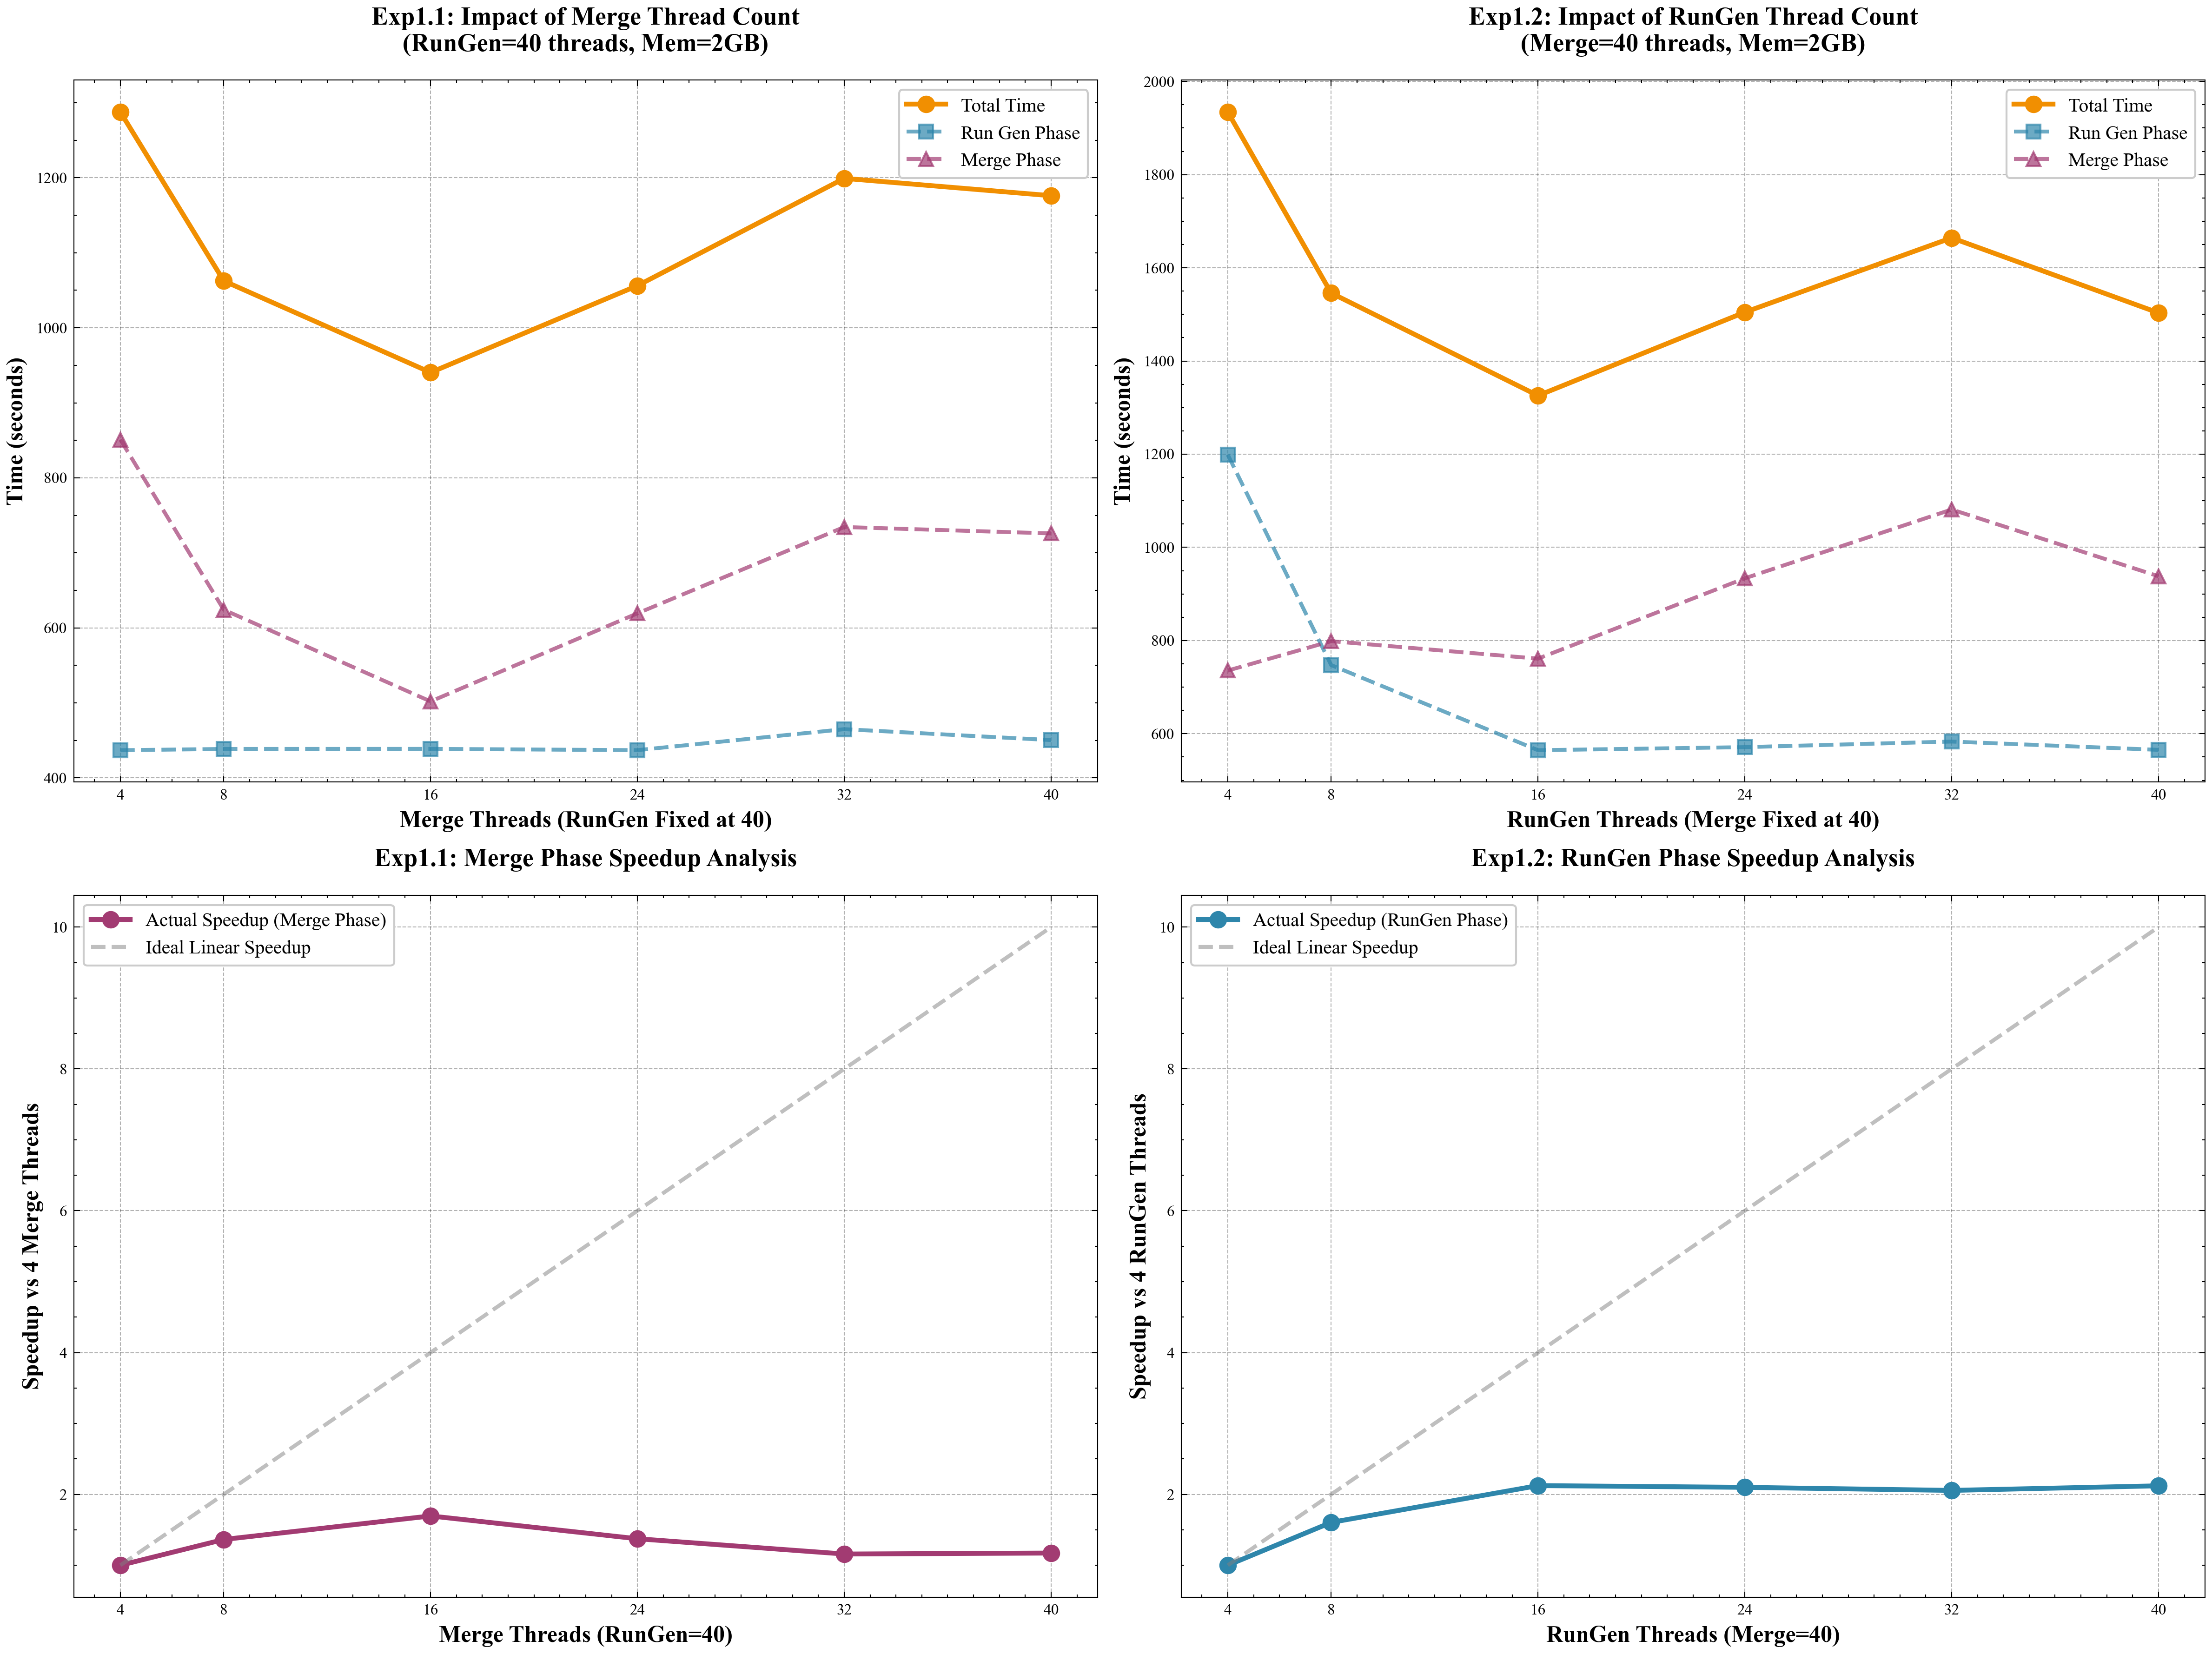


KEY INSIGHTS: RunGen vs Merge Thread Impact

Exp1.1 (Fixed RunGen=40, Varying Merge):
  Merge time: 4 threads = 850.87s, 40 threads = 725.85s
  Speedup: 1.17x (efficiency: 11.7%)

Exp1.2 (Fixed Merge=40, Varying RunGen):
  RunGen time: 4 threads = 1198.80s, 40 threads = 565.33s
  Speedup: 2.12x (efficiency: 21.2%)


In [100]:
# Plot: Exp1.1/1.2 - Individual thread impact on RunGen vs Merge
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

colors_phases = {
    'rungen': '#2E86AB',
    'merge': '#A23B72',
    'total': '#F18F01'
}

# ----- Plot 1: Exp1.1 - Fixed RunGen=40, Varying Merge Threads -----
ax1.plot(df_exp1_1['merge_threads'], df_exp1_1['total_time'],
         'o-', lw=2.5, markersize=8, color=colors_phases['total'], label='Total Time')
ax1.plot(df_exp1_1['merge_threads'], df_exp1_1['rungen_time'],
         's--', lw=2, markersize=7, alpha=0.7, color=colors_phases['rungen'], label='Run Gen Phase')
ax1.plot(df_exp1_1['merge_threads'], df_exp1_1['merge_time'],
         '^--', lw=2, markersize=7, alpha=0.7, color=colors_phases['merge'], label='Merge Phase')

ax1.set_xlabel('Merge Threads (RunGen Fixed at 40)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Exp1.1: Impact of Merge Thread Count\n(RunGen=40 threads, Mem=2GB)',
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_exp1_1['merge_threads'])

# ----- Plot 2: Exp1.2 - Varying RunGen Threads, Fixed Merge=40 -----
ax2.plot(df_exp1_2['rungen_threads'], df_exp1_2['total_time'],
         'o-', lw=2.5, markersize=8, color=colors_phases['total'], label='Total Time')
ax2.plot(df_exp1_2['rungen_threads'], df_exp1_2['rungen_time'],
         's--', lw=2, markersize=7, alpha=0.7, color=colors_phases['rungen'], label='Run Gen Phase')
ax2.plot(df_exp1_2['rungen_threads'], df_exp1_2['merge_time'],
         '^--', lw=2, markersize=7, alpha=0.7, color=colors_phases['merge'], label='Merge Phase')

ax2.set_xlabel('RunGen Threads (Merge Fixed at 40)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Exp1.2: Impact of RunGen Thread Count\n(Merge=40 threads, Mem=2GB)',
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(df_exp1_2['rungen_threads'])

# ----- Plot 3: Speedup Analysis - Merge Thread Impact -----
merge_baseline = df_exp1_1[df_exp1_1['merge_threads'] == 4]['merge_time'].values[0]
merge_speedup = merge_baseline / df_exp1_1['merge_time']
merge_ideal = df_exp1_1['merge_threads'] / 4

ax3.plot(df_exp1_1['merge_threads'], merge_speedup,
         'o-', lw=2.5, markersize=8, color=colors_phases['merge'], label='Actual Speedup (Merge Phase)')
ax3.plot(df_exp1_1['merge_threads'], merge_ideal,
         '--', lw=2, alpha=0.5, color='gray', label='Ideal Linear Speedup')

ax3.set_xlabel('Merge Threads (RunGen=40)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Speedup vs 4 Merge Threads', fontsize=12, fontweight='bold')
ax3.set_title('Exp1.1: Merge Phase Speedup Analysis', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(df_exp1_1['merge_threads'])

# ----- Plot 4: Speedup Analysis - RunGen Thread Impact -----
rungen_baseline = df_exp1_2[df_exp1_2['rungen_threads'] == 4]['rungen_time'].values[0]
rungen_speedup = rungen_baseline / df_exp1_2['rungen_time']
rungen_ideal = df_exp1_2['rungen_threads'] / 4

ax4.plot(df_exp1_2['rungen_threads'], rungen_speedup,
         'o-', lw=2.5, markersize=8, color=colors_phases['rungen'], label='Actual Speedup (RunGen Phase)')
ax4.plot(df_exp1_2['rungen_threads'], rungen_ideal,
         '--', lw=2, alpha=0.5, color='gray', label='Ideal Linear Speedup')

ax4.set_xlabel('RunGen Threads (Merge=40)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Speedup vs 4 RunGen Threads', fontsize=12, fontweight='bold')
ax4.set_title('Exp1.2: RunGen Phase Speedup Analysis', fontsize=13, fontweight='bold', pad=15)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(df_exp1_2['rungen_threads'])

plt.tight_layout()
dataset_name = LOG_DIR.split('/')[-1].replace('_result', '')
plt.savefig(os.path.join(OUTPUT_DIR, f'{dataset_name}_exp1_thread_impact_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print key insights
print("\n" + "="*80)
print("KEY INSIGHTS: RunGen vs Merge Thread Impact")
print("="*80)

print("\nExp1.1 (Fixed RunGen=40, Varying Merge):")
merge_4 = df_exp1_1[df_exp1_1['merge_threads'] == 4]['merge_time'].values[0]
merge_40 = df_exp1_1[df_exp1_1['merge_threads'] == 40]['merge_time'].values[0]
print(f"  Merge time: 4 threads = {merge_4:.2f}s, 40 threads = {merge_40:.2f}s")
print(f"  Speedup: {merge_4/merge_40:.2f}x (efficiency: {(merge_4/merge_40)/(40/4)*100:.1f}%)")

print("\nExp1.2 (Fixed Merge=40, Varying RunGen):")
rungen_4 = df_exp1_2[df_exp1_2['rungen_threads'] == 4]['rungen_time'].values[0]
rungen_40 = df_exp1_2[df_exp1_2['rungen_threads'] == 40]['rungen_time'].values[0]
print(f"  RunGen time: 4 threads = {rungen_4:.2f}s, 40 threads = {rungen_40:.2f}s")
print(f"  Speedup: {rungen_4/rungen_40:.2f}x (efficiency: {(rungen_4/rungen_40)/(40/4)*100:.1f}%)")


### Exp1.1: Merge Thread Impact (4-16 threads)


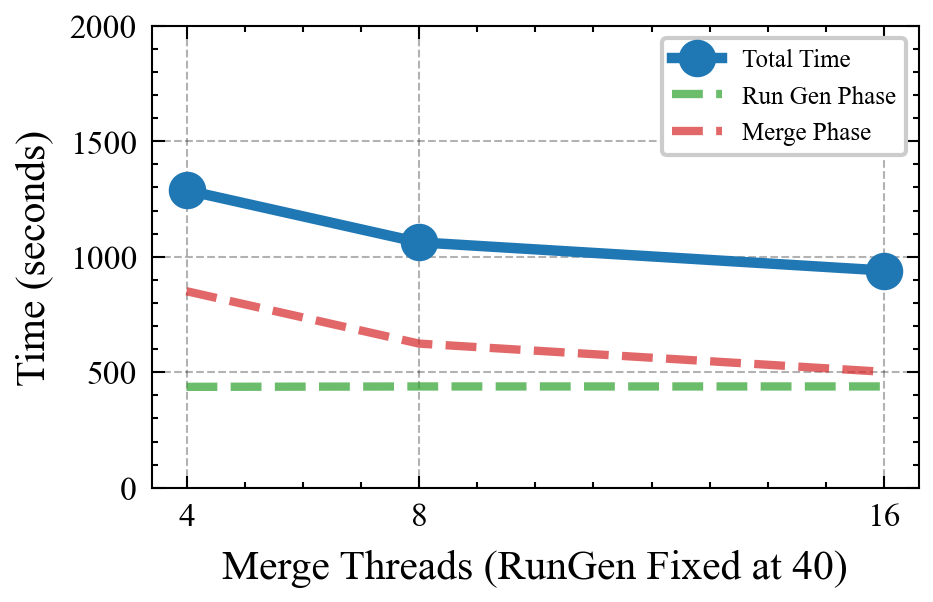


Exp1.1 Insights (Fixed RunGen=40, Varying Merge 4-16):
  Merge time: 4 threads = 850.87s, 16 threads = 501.84s
  Speedup: 1.70x (efficiency: 42.4%)


In [101]:
# Exp1.1: Low Thread Count Analysis (4-16 threads) - Merge Threads
df_exp1_1_low = df_exp1_1[df_exp1_1['merge_threads'] <= 16].copy()

fig, ax = plt.subplots()

ax.plot(df_exp1_1_low['merge_threads'], df_exp1_1_low['total_time'],
         'o-', lw=2.5, markersize=8, color=colors['total'], label='Total Time')
ax.plot(df_exp1_1_low['merge_threads'], df_exp1_1_low['rungen_time'],
         '--', lw=2, alpha=0.7, color=colors['rungen'], label='Run Gen Phase')
ax.plot(df_exp1_1_low['merge_threads'], df_exp1_1_low['merge_time'],
         '--', lw=2, alpha=0.7, color=colors['merge'], label='Merge Phase')

ax.set_xlabel('Merge Threads (RunGen Fixed at 40)')
ax.set_ylabel('Time (seconds)')
# ax.set_title('Exp1.1: Impact of Merge Thread Count\n(RunGen=40 threads, Mem=2GB, 4-16 threads)',
#               fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(df_exp1_1_low['merge_threads'])
ax.set_ylim(bottom=0, top=2000)

dataset_name = LOG_DIR.split('/')[-1].replace('_result', '')
plt.savefig(os.path.join(OUTPUT_DIR, f'{dataset_name}_exp1_1_merge_threads_4_16.png'), dpi=300)
plt.show()

# Print insights
if 4 in df_exp1_1_low['merge_threads'].values and 16 in df_exp1_1_low['merge_threads'].values:
    print("\nExp1.1 Insights (Fixed RunGen=40, Varying Merge 4-16):")
    merge_4 = df_exp1_1_low[df_exp1_1_low['merge_threads'] == 4]['merge_time'].values[0]
    merge_16 = df_exp1_1_low[df_exp1_1_low['merge_threads'] == 16]['merge_time'].values[0]
    print(f"  Merge time: 4 threads = {merge_4:.2f}s, 16 threads = {merge_16:.2f}s")
    print(f"  Speedup: {merge_4/merge_16:.2f}x (efficiency: {(merge_4/merge_16)/(16/4)*100:.1f}%)")

### Exp1.2: RunGen Thread Impact (4-16 threads)


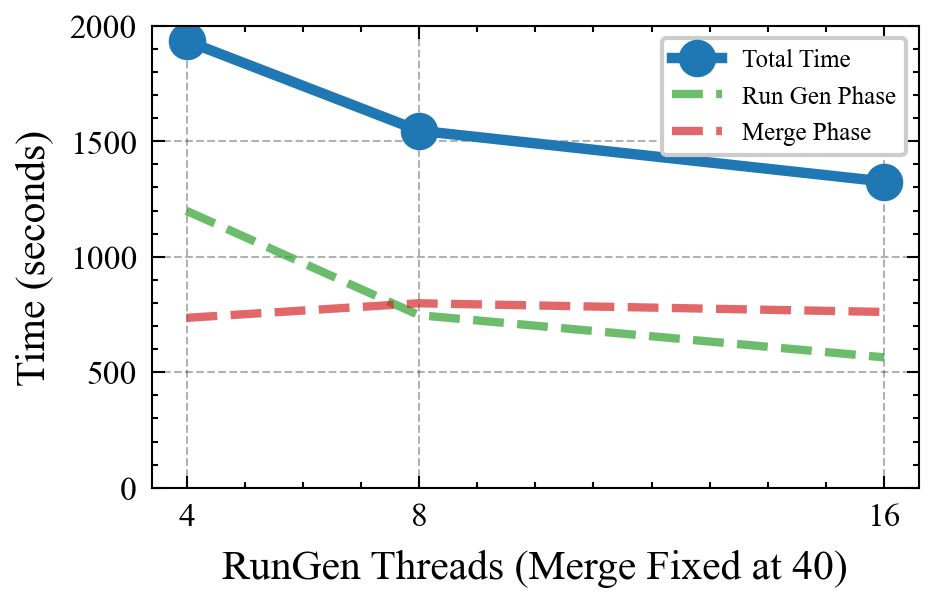


Exp1.2 Insights (Fixed Merge=40, Varying RunGen 4-16):
  RunGen time: 4 threads = 1198.80s, 16 threads = 564.56s
  Speedup: 2.12x (efficiency: 53.1%)


In [102]:
# Exp1.2: Low Thread Count Analysis (4-16 threads) - RunGen Threads
df_exp1_2_low = df_exp1_2[df_exp1_2['rungen_threads'] <= 16].copy()

fig, ax = plt.subplots()

ax.plot(df_exp1_2_low['rungen_threads'], df_exp1_2_low['total_time'],
         'o-', lw=2.5, markersize=8, color=colors['total'], label='Total Time')
ax.plot(df_exp1_2_low['rungen_threads'], df_exp1_2_low['rungen_time'],
         '--', lw=2, alpha=0.7, color=colors['rungen'], label='Run Gen Phase')
ax.plot(df_exp1_2_low['rungen_threads'], df_exp1_2_low['merge_time'],
         '--', lw=2, alpha=0.7, color=colors['merge'], label='Merge Phase')

ax.set_xlabel('RunGen Threads (Merge Fixed at 40)')
ax.set_ylabel('Time (seconds)')
# ax.set_title('Exp1.2: Impact of RunGen Thread Count\n(Merge=40 threads, Mem=2GB, 4-16 threads)',
#               fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(df_exp1_2_low['rungen_threads'])
ax.set_ylim(bottom=0, top=2000)

# plt.tight_layout()
dataset_name = LOG_DIR.split('/')[-1].replace('_result', '')
plt.savefig(os.path.join(OUTPUT_DIR, f'{dataset_name}_exp1_2_rungen_threads_4_16.png'), dpi=300)
plt.show()

# Print insights
if 4 in df_exp1_2_low['rungen_threads'].values and 16 in df_exp1_2_low['rungen_threads'].values:
    print("\nExp1.2 Insights (Fixed Merge=40, Varying RunGen 4-16):")
    rungen_4 = df_exp1_2_low[df_exp1_2_low['rungen_threads'] == 4]['rungen_time'].values[0]
    rungen_16 = df_exp1_2_low[df_exp1_2_low['rungen_threads'] == 16]['rungen_time'].values[0]
    print(f"  RunGen time: 4 threads = {rungen_4:.2f}s, 16 threads = {rungen_16:.2f}s")
    print(f"  Speedup: {rungen_4/rungen_16:.2f}x (efficiency: {(rungen_4/rungen_16)/(16/4)*100:.1f}%)")

### Thread Configuration Comparison
Comparing 4 thread configurations: (RunGen, Merge) = (16, 40), (24, 24), (40, 16), (40, 40)
